# Notebook 2 of 3 -- Project Walkthrough, Part 1: Replicating the Client's Data-Collection Framework and Its Accuracy-Centric QA Baseline

> **Trace**
> - **Paper:** ALL (P1, P2, P3 are named as Notebook 3's targets; Notebook 2 applies none of them)
> - **Result and query:** the on-policy vs off-policy passage from P1 -- `q9`
> - **Status:** QUOTED (the `q9` passage)

This is the second notebook in a three-part portfolio series built around an Upwork job posting
("AI Alignment / Post-Training Researcher", full text in `research/job-posting.md`). The client
runs a human data-collection pipeline that produces **reasoning traces** (for SFT/CoT), **rubrics**
(reward signal for GRPO-style training), and **preference pairs** (for DPO). The job asks for
someone who can "look at a human-written reasoning trace or rubric and predict whether it will
create a useful gradient signal for a model" and give "sharp, actionable feedback on our data
collection framework." That is the deliverable this three-notebook series scaffolds toward.

**Important framing.** Everything below is a *draft scaffold*, not a finished audit and not a
claim of prior production experience with this specific client's real system. The client's
"framework" itself is **hypothetical**: it is this project's replication of what the job posting
describes (traces, rubrics, preference pairs feeding SFT/DPO/GRPO), not the client's actual
pipeline, which we have never seen. Every threshold, rubric wording, and generator choice here is
left open for a human collaborator to reshape.

**What this notebook does and does not do.** Notebook 2 (this one) builds a synthetic corpus with
**known latent truth** and replicates the kind of **accuracy-centric QA baseline** a typical
vendor dashboard reports (final-answer correctness, inter-annotator agreement, rubric pairwise
accuracy, verifier agreement -- all with honest Wilson intervals). It deliberately stops there.
Notebook 3 (built later, reusing this notebook's code verbatim -- see the reuse contract in `## 8`)
applies three research papers to show what an accuracy-centric baseline like this one misses:

- **signal magnitude** -- reward variance under the student policy's *own* samples (Razin et al.,
  *What Makes a Reward Model a Good Teacher?*, NeurIPS 2025, arXiv:2503.15477);
- **signal direction in the high-reward tail** -- rubric tail accuracy (Zhang et al., *Chasing the
  Tail*, ICLR 2026, arXiv:2509.21500);
- **side effects of preference pairs** -- likelihood displacement / CHES (Razin et al.,
  *Unintentional Unalignment*, ICLR 2025, arXiv:2410.08847).

**Why synthetic data with a known latent truth.** A real audit of "is this rubric accurate,
does this verifier agree with experts, do annotators agree with each other" needs *something to
check against*. Real human-collected traces and rubrics don't come with an answer key -- that's
exactly the thing being audited. Building a synthetic generator that stamps every task, response,
and preference pair with its "true" quality at generation time means every claim below ("the
audit's 95% CI covers the population truth", "the coarse rubric ties great and excellent
responses X% of the time") is a checkable fact about the generator, not an assertion about the
real world.

**On-policy vs. off-policy, quoted from the source papers (`q9`):**
> "The preferred and dispreferred responses can be obtained by generating two candidate responses
> from the model (i.e. on-policy), and labeling them via human or AI raters... Alternatively, they
> can be taken from some static dataset (i.e. off-policy). Our analysis and experiments capture
> both cases." (Razin et al. 2410.08847, `q9`)

This matters for the client's world too: a client's **human-written exemplars are off-policy**
relative to whatever student model is being trained, while the student's own rollouts are
on-policy. `## 2` below builds both kinds and keeps them labeled, because Notebook 3's
reward-variance analysis is specifically about the student's *own* on-policy samples (`q9`,
research-context rule 6).

## How to trace any text cell back to a paper

Every markdown section, and every "How to read this chart" cell, opens with a `Trace` box:

> **Trace**
> - **Paper:** which paper the cell rests on (a tag from the first table below)
> - **Result and query:** the exact theorem / definition / table, and the NotebookLM slug (`qN`) that quotes it
> - **Status:** one label (or more) from the second table below

**Paper tags** (identical in all three notebooks):

| Tag | Paper | Venue | What it diagnoses | NotebookLM slugs |
|---|---|---|---|---|
| **P1** | Razin, Malladi, Bhaskar, Chen, Arora, Hanin. *Unintentional Unalignment: Likelihood Displacement in DPO* | ICLR 2025, arXiv:2410.08847 | side effects on the preferred response (CHES) | `q2` theory, `q3` experiments |
| **P2** | Razin, Wang, Strauss, Wei, Lee, Arora. *What Makes a Reward Model a Good Teacher?* | NeurIPS 2025, arXiv:2503.15477 | signal magnitude (on-policy reward variance) | `q4` theory, `q5` experiments |
| **P3** | Zhang, Wang, Gui, et al. *Chasing the Tail: Effective Rubric-based Reward Modeling for LLM Post-Training* | ICLR 2026, arXiv:2509.21500 | signal direction in the high-reward tail (rubric tail accuracy) | `q6` theory, `q7` rubric and experiments |
| **ALL** | questions that span the three papers | -- | -- | `q1` setup, `q8` hyperparameters, `q9` on/off-policy, `q10` operational procedures, `q11` limitations, `q12` cross-paper synthesis and gaps (NotebookLM's own synthesis, not paper text) |

**Status labels:**

| Status | Meaning |
|---|---|
| QUOTED | text or an equation taken from a paper via NotebookLM; re-read it with `research/reread.sh N` |
| PAPER NUMBER | a number the paper reports, shown for comparison and not reproduced here |
| TOY CHECK | this notebook's own simulation testing a paper's claim in an idealised setting |
| DERIVED HERE | not in any of the three papers: our own derivation, construction or design choice |
| CONVENTION REUSED | a paper's measurement convention applied to our own data |
| NONE | no paper involved (generator design or bookkeeping) |

**Number collisions.** P1 and P2 both have a Definition 2, a Theorem 4, a Theorem 5 and a Proposition 3, and they are different results. P1: Definition 2 is CHES, Theorem 4 is the single-token derivative, Theorem 5 says which tokens gain probability mass, Proposition 3 (Appendix F) is the frozen-embedding monotonicity result. P2: Definition 2 is reward variance, Theorem 4 is the general lower bound on the time $t_\gamma$, Theorem 5 says accuracy does not determine speed, Proposition 3 (Appendix C.6) is the tabular lower bound. A bare "Theorem 5" in a Trace box is always tagged P1 or P2.


## Initial project idea (draft, open to revision)

> **Trace**
> - **Paper:** P3 and P1, as design inspirations
> - **Result and query:** P3's rubric reward formula -- `q7`; near-duplicate pairs as a high-CHES risk in P1 -- `q2`, `q3`, `q10`
> - **Status:** CONVENTION REUSED (P3's formula); everything else DERIVED HERE (a project plan, not a paper claim)

The idea sketched here is a **replication-plus-audit harness for a human data-collection
framework that feeds SFT, DPO, and GRPO**:

1. Build a small **synthetic task bank with known latent truth** (`## 1`): multi-step arithmetic
   word problems, each stamped with a difficulty, a student-model solve probability, and (for
   ~15% of tasks) a genuine wording ambiguity governed by a written style guide.
2. Generate **candidate responses** the way a real pipeline would see them (`## 2`): on-policy
   student rollouts (8 per task, sampled from a documented latent policy) plus off-policy
   human-written exemplars (2 per task), each with a latent quality that a coarse rubric can miss.
3. Replicate the client's **rubric + verifier** machinery (`## 3`) exactly as Paper 3's formula
   (`r = Σ wᵢV(x,y,cᵢ)/Σwᵢ`), with a simulated noisy verifier and a real (capped, cached) LLM
   verifier smoke test (`## 4`).
4. Replicate **preference-pair collection** (`## 5`): different-quality pairs, near-duplicate
   pairs (minimal edits -- the kind Paper 1 flags as high-CHES risk), verification-added pairs,
   and off-policy-vs-on-policy pairs, each with two simulated annotators and an expert gold label.
5. Run the **accuracy-centric QA baseline** (`## 6`) that a typical vendor dashboard reports --
   correctness rates, inter-annotator agreement, rubric pairwise accuracy, verifier agreement --
   with Wilson 95% intervals, and check whether those intervals actually cover the truth (since,
   uniquely here, the truth is known).
6. State the **hypothesis, not yet a result** (`## 6`, `## 8`): this dashboard can look healthy
   while missing low on-policy reward variance, tail misranking, and near-duplicate preference
   pairs -- the three things Notebook 3 measures directly.

The eventual deliverable this scaffolds toward -- written feedback on a real data-collection
framework, backed by numbers like these -- is **not** built in this notebook. See `## 8` for the
engineering choices and gaps left open.

## Dataset rationale

> **Trace**
> - **Paper:** none
> - **Result and query:** dataset choice
> - **Status:** DERIVED HERE

The natural real-world stand-in for this problem is a **GSM8K-style corpus of grade-school math
word problems** (multi-step arithmetic, integer answers, short natural-language phrasing) -- the
kind of task family commonly used as a first testbed for CoT reasoning, rubric rewards, and
RLVR/GRPO in the literature this project's source papers sit in. (Its exact size and license
terms are not stated here, since neither was verified for this notebook; a real project would
pin an exact version before using it.)

It is **not downloaded here**, for the same reason `01_research_foundations.ipynb`-style notebooks
in this series don't download real data for their audit sections: a rubric/verifier/annotator
audit needs a **known** ground truth to check every claim against, and real GSM8K problems solved
by real annotators would need exactly the human labeling effort this notebook's pipeline is being
built to audit -- a circularity. Instead, `## 1` builds a **synthetic generator with known latent
truth**: every task is stamped with a difficulty, a solve probability, and (for the ambiguous
subset) two valid readings and a style-guide-designated gold one, all *by construction*, so every
audit claim in `## 6` and `## 7` is checkable in this notebook rather than asserted about the real
world. Swapping in a real GSM8K-style set (with real human labels replacing the latent truth) is
one of the engineering choices left open in `## 8`.

In [1]:
%matplotlib inline
import hashlib
import json
import math
import os
import re
import threading
import time
import urllib.error
import urllib.request
from collections import Counter
from pathlib import Path
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 20260917
RNG = np.random.default_rng(SEED)

NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR.parent / "data"
NB2_DIR = DATA_DIR / "nb2"
CACHE_DIR = DATA_DIR / "llm_cache" / "deepseek"
NB2_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# One palette, reused by every chart in this notebook.
PALETTE = {
    "student": "#1f77b4", "human": "#d62728",
    "excellent": "#2ca02c", "great": "#1f77b4", "lucky_correct": "#bcbd22",
    "incorrect": "#7f7f7f",
    "coarse": "#ff7f0e", "sharp": "#9467bd",
    "ambiguous": "#d62728", "non_ambiguous": "#1f77b4",
    "estimate": "#1f77b4", "truth": "#d62728", "population": "#2ca02c",
    "plus": "#2ca02c", "minus": "#7f7f7f", "tie": "#bcbd22",
    "a_diff_quality": "#1f77b4", "b_near_duplicate": "#d62728",
    "c_add_verification": "#2ca02c", "d_human_vs_student": "#9467bd",
}


def wilson_ci(k: int, n: int, alpha: float = 0.05) -> tuple:
    if n == 0:
        return (0.0, 1.0)
    z = NormalDist().inv_cdf(1 - alpha / 2)
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2 * n)) / denom
    half = (z * math.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2))) / denom
    return (max(0.0, center - half), min(1.0, center + half))


def fmt_ci(ci):
    return f"[{ci[0]:.3f}, {ci[1]:.3f}]" if ci is not None else "n/a"


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


print("setup OK. NOTEBOOK_DIR =", NOTEBOOK_DIR, " DATA_DIR =", DATA_DIR)

setup OK. NOTEBOOK_DIR = /home/centos/data/projects/for-money/computer-science/upwork/flex-projects/alignment-post-training/notebooks  DATA_DIR = /home/centos/data/projects/for-money/computer-science/upwork/flex-projects/alignment-post-training/data


## 1. Synthetic task bank with latent truth

> **Trace**
> - **Paper:** none in this section; it prepares objects for P2 and P3
> - **Result and query:** the on-policy solve probability that P2 measures variance and accuracy against -- `q4`, `q5` -- and the tail region P3 studies -- `q6`, `q7`; both are applied in Notebook 3, not here
> - **Status:** DERIVED HERE (generator design); CHECK 1.1-1.5 are generator sanity checks, not paper tests

**Claim.** We can build a task bank where every item carries its own "true" difficulty, a student
policy's latent solve probability, and (for a documented ~15% subset) a genuine wording ambiguity
with a style-guide-designated gold reading -- all *by construction*, so `## 6`/`## 7` can check
audit claims against something real instead of assuming they're right.

No paper re-read is needed for this section (it is pure generator design), but it sets up the
on-policy solve-probability object Paper 2 measures reward variance and accuracy against in `q4`/`q5`
(deferred to Notebook 3) and the tail region Paper 3 studies in `q6`/`q7` (also deferred).

**Design.** ~60 multi-step arithmetic word problems across 4 templates (shopping change, multi-leg
travel distance, an inclusive/exclusive day-range count, and a "how many more X" comparison across
multiple days), difficulty 1-4 (2-4 arithmetic steps). Two of the four templates can host a
**genuine two-reading ambiguity**:
- `inclusive_exclusive`: "day A through day B" can be read inclusively (both endpoints count,
  the style-guide gold reading here) or exclusively.
- `more_total`: "how many more did A do than B" can be read as comparing **combined totals across
  all days** (gold) or just the **last day alone**.

A written style guide (the two bullet points above) defines the gold reading. On these ~15% of
tasks, a response that picks the other reading is **not making an arithmetic error** -- it is
disagreeing with a wording convention, which is a finding about guideline clarity, not a mistake.
That distinction is threaded through every response and rubric-criterion feature below via
`follows_style_guide_reading` and `matches_gold_answer` (`## 2`).

In [2]:
NAMES = ["Maria", "Diego", "Aisha", "Noah", "Priya", "Liam", "Yuki", "Omar", "Elena", "Kofi",
         "Sofia", "Ravi", "Chen", "Fatima", "Lucas", "Ingrid"]
ITEMS = [("notebook", 3), ("pen", 2), ("eraser", 1), ("ruler", 2), ("marker", 3), ("folder", 2)]
UNIT_MONEY = "dollars"


def pick_distractor(base, exclude, choices, rng):
    # base +/- a nonzero offset from `choices`, guaranteed distinct from every value in `exclude`.
    exclude = set(v for v in exclude if v is not None)
    offsets = list(choices)
    rng.shuffle(offsets)
    for off in offsets:
        cand = base + off
        if cand not in exclude:
            return cand
    return base + max(choices) + 7


def make_task_shopping(difficulty, rng):
    n_items = {1: 2, 2: 2, 3: 3, 4: 3}[difficulty]
    chosen = rng.choice(len(ITEMS), size=n_items, replace=False)
    lines, steps, total = [], [], 0
    for idx in chosen:
        name, base_price = ITEMS[idx]
        qty = int(rng.integers(2, 6))
        price = base_price + int(rng.integers(0, 3))
        cost = qty * price
        total += cost
        lines.append(f"{qty} {name}s at ${price} each")
        steps.append((f"{qty} {name}s x ${price}", cost))
    bill = int(math.ceil((total + rng.integers(5, 25)) / 5) * 5)
    change = bill - total
    steps.append((f"total ${total}, paid with a ${bill} bill", change))
    buyer = NAMES[rng.integers(0, len(NAMES))]
    text = f"{buyer} buys " + ", ".join(lines) + f", and pays with a ${bill} bill. How much change does {buyer} get back?"
    return {"template": "shopping_change", "problem_text": text, "steps_gold": steps, "steps_alt": None,
            "answer_gold": change, "answer_alt": None,
            "distractor_answer": pick_distractor(change, [change], [-3, -2, -1, 1, 2, 3], rng),
            "unit": UNIT_MONEY, "ambiguity_type": None}


def make_task_travel(difficulty, rng):
    n_legs = {1: 2, 2: 2, 3: 3, 4: 3}[difficulty]
    traveler = NAMES[rng.integers(0, len(NAMES))]
    legs, steps, total = [], [], 0
    for _ in range(n_legs):
        speed = int(rng.integers(20, 70))
        hours = int(rng.integers(1, 5))
        dist = speed * hours
        total += dist
        legs.append(f"{hours} hours at {speed} mph")
        steps.append((f"{hours}h x {speed}mph", dist))
    if difficulty == 4:
        back = int(rng.integers(5, 40))
        total -= back
        steps.append((f"then backtracks {back} miles", total))
        extra = f" Then {traveler} backtracks {back} miles."
    else:
        extra = ""
        steps.append(("total distance", total))  # explicit final step, so it always equals answer_gold
    text = (f"{traveler} travels " + ", then ".join(legs) + f".{extra} "
            f"How many total miles does {traveler} travel?")
    return {"template": "travel_distance", "problem_text": text, "steps_gold": steps, "steps_alt": None,
            "answer_gold": total, "answer_alt": None,
            "distractor_answer": pick_distractor(total, [total], [-15, -10, -5, 5, 10, 15], rng),
            "unit": "miles", "ambiguity_type": None}


def make_task_inclusive_range(difficulty, rng, ambiguous):
    name = NAMES[rng.integers(0, len(NAMES))]
    activities = ["walks to school", "practices piano", "waters the garden", "does a workout"]
    activity = activities[rng.integers(0, len(activities))]
    a = int(rng.integers(2, 10))
    b = a + int(rng.integers(8, 20))
    incl, excl = b - a + 1, b - a
    extra_days = int(rng.integers(1, 6)) if difficulty >= 3 else 0
    gold_total, alt_total = incl + extra_days, excl + extra_days
    steps_gold = [(f"day {a} through day {b}, inclusive", incl)]
    steps_alt = [(f"day {a} through day {b}, exclusive of day {a}", excl)]
    if extra_days:
        steps_gold.append((f"plus {extra_days} extra day(s)", gold_total))
        steps_alt.append((f"plus {extra_days} extra day(s)", alt_total))
    extra_txt = f" {name} also does it on {extra_days} extra day(s)." if extra_days else ""
    if ambiguous:
        text = (f"{name} {activity} starting on day {a} through day {b}.{extra_txt}"
                " How many days in total does this add up to?")
    else:
        text = (f"{name} {activity} every day starting on day {a} and ending on day {b}, "
                f"counting both day {a} and day {b}.{extra_txt} How many days in total?")
    return {"template": "inclusive_range", "problem_text": text, "steps_gold": steps_gold,
            "steps_alt": steps_alt if ambiguous else None, "answer_gold": gold_total,
            "answer_alt": alt_total if ambiguous else None,
            "distractor_answer": pick_distractor(gold_total, [gold_total, alt_total], [-3, -2, 2, 3], rng),
            "unit": "days", "ambiguity_type": "inclusive_exclusive" if ambiguous else None}


def make_task_more_total(difficulty, rng, ambiguous):
    nameA = NAMES[rng.integers(0, len(NAMES))]
    nameB = NAMES[rng.integers(0, len(NAMES))]
    while nameB == nameA:
        nameB = NAMES[rng.integers(0, len(NAMES))]
    n_days = 3 if difficulty >= 3 else 2
    a_days = [int(rng.integers(3, 20)) for _ in range(n_days)]
    b_days = [int(rng.integers(3, 20)) for _ in range(n_days)]
    if sum(a_days) < sum(b_days):  # keep the "how many MORE" total non-negative
        a_days, b_days = b_days, a_days
    total_gold = sum(a_days) - sum(b_days)
    last_alt = a_days[-1] - b_days[-1]
    day_words = ["Monday", "Tuesday", "Wednesday"][:n_days]
    parts = [f"{amt} apples on {day}" for amt, day in zip(a_days, day_words)]
    partsB = [f"{amt} apples on {day}" for amt, day in zip(b_days, day_words)]
    steps_gold = [(f"{nameA} total", sum(a_days)), (f"{nameB} total", sum(b_days)),
                  ("difference of totals", total_gold)]
    steps_alt = [(f"{nameA} on {day_words[-1]}", a_days[-1]), (f"{nameB} on {day_words[-1]}", b_days[-1]),
                 ("difference on the last day only", last_alt)]
    if ambiguous:
        text = (f"{nameA} picked " + " and ".join(parts) + f". {nameB} picked " + " and ".join(partsB)
                + f". How many more apples did {nameA} pick than {nameB}?")
    else:
        text = (f"{nameA} picked " + " and ".join(parts) + f". {nameB} picked " + " and ".join(partsB)
                + f". Combining all days, how many more apples did {nameA} pick than {nameB} in total?")
    return {"template": "more_total", "problem_text": text, "steps_gold": steps_gold,
            "steps_alt": steps_alt if ambiguous else None, "answer_gold": total_gold,
            "answer_alt": last_alt if ambiguous else None,
            "distractor_answer": pick_distractor(total_gold, [total_gold, last_alt], [-4, -2, 2, 4], rng),
            "unit": None, "ambiguity_type": "more_total" if ambiguous else None}


def build_task_bank():
    rng = np.random.default_rng(SEED + 1)
    amb_rng = np.random.default_rng(SEED + 2)
    tasks, tid = [], 0
    diffs_15 = [1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4]
    templates_plan = ["shopping_change", "travel_distance", "inclusive_range", "more_total"]
    amb_chosen = set(amb_rng.choice(30, size=9, replace=False).tolist())  # 9/30 ambiguity-capable slots
    slot_counter = 0
    for template in templates_plan:
        for difficulty in diffs_15:
            tid += 1
            if template == "shopping_change":
                t, ambiguous = make_task_shopping(difficulty, rng), False
            elif template == "travel_distance":
                t, ambiguous = make_task_travel(difficulty, rng), False
            elif template == "inclusive_range":
                ambiguous = slot_counter in amb_chosen
                t, slot_counter = make_task_inclusive_range(difficulty, rng, ambiguous), slot_counter + 1
            else:
                ambiguous = slot_counter in amb_chosen
                t, slot_counter = make_task_more_total(difficulty, rng, ambiguous), slot_counter + 1
            t["task_id"] = f"T{tid:03d}"
            t["difficulty"] = difficulty
            t["ambiguous"] = bool(ambiguous)
            noise = rng.normal(0, 1.5)  # deliberately wide spread: some p near 0, some near 1
            p = sigmoid(3.0 - 1.1 * difficulty + noise)
            t["p_solve"] = float(np.clip(p, 0.02, 0.98))
            tasks.append(t)
    return tasks


TASKS = build_task_bank()
TASKS_BY_ID = {t["task_id"]: t for t in TASKS}
TASKS_DF = pd.DataFrame([{k: v for k, v in t.items() if k not in ("steps_gold", "steps_alt")} for t in TASKS])

n_amb = int(TASKS_DF["ambiguous"].sum())
print(f"[CHECK 1.1] n tasks = {len(TASKS)} (expect 60): {'PASS' if len(TASKS) == 60 else 'FAIL'}")
print(f"[CHECK 1.2] n ambiguous = {n_amb} ({n_amb/len(TASKS)*100:.1f}%, target ~15%): "
      f"{'PASS' if 0.10 <= n_amb/len(TASKS) <= 0.20 else 'FAIL'}")
ps = TASKS_DF["p_solve"].to_numpy()
print(f"[CHECK 1.3] p_solve spread: min={ps.min():.3f} max={ps.max():.3f} "
      f"n<0.1={int((ps<0.1).sum())} n>0.9={int((ps>0.9).sum())} "
      f"({'PASS' if ps.min() < 0.1 and ps.max() > 0.9 else 'FAIL'} -- some near 0, some near 1)")
print(f"[CHECK 1.4] template counts: {dict(TASKS_DF['template'].value_counts())}")
print(f"[CHECK 1.5] every ambiguous task has a non-null answer_alt distinct from answer_gold: "
      f"{'PASS' if all(t['answer_alt'] != t['answer_gold'] for t in TASKS if t['ambiguous']) else 'FAIL'}")

TASKS_DF.to_json(NB2_DIR / "tasks.json", orient="records", indent=2)
print(f"wrote {NB2_DIR / 'tasks.json'}")
for t in [x for x in TASKS if not x["ambiguous"]][:1] + [x for x in TASKS if x["ambiguous"]][:2]:
    print("---", t["task_id"], t["template"], "difficulty", t["difficulty"], "ambiguous", t["ambiguous"])
    print(" ", t["problem_text"])
    print("  gold:", t["answer_gold"], " alt:", t["answer_alt"], " p_solve:", round(t["p_solve"], 3))

[CHECK 1.1] n tasks = 60 (expect 60): PASS
[CHECK 1.2] n ambiguous = 9 (15.0%, target ~15%): PASS
[CHECK 1.3] p_solve spread: min=0.032 max=0.944 n<0.1=7 n>0.9=9 (PASS -- some near 0, some near 1)
[CHECK 1.4] template counts: {'shopping_change': np.int64(15), 'travel_distance': np.int64(15), 'inclusive_range': np.int64(15), 'more_total': np.int64(15)}
[CHECK 1.5] every ambiguous task has a non-null answer_alt distinct from answer_gold: PASS
wrote /home/centos/data/projects/for-money/computer-science/upwork/flex-projects/alignment-post-training/data/nb2/tasks.json
--- T001 shopping_change difficulty 1 ambiguous False
  Elena buys 2 rulers at $4 each, 5 folders at $2 each, and pays with a $45 bill. How much change does Elena get back?
  gold: 27  alt: None  p_solve: 0.803
--- T033 inclusive_range difficulty 1 ambiguous True
  Diego waters the garden starting on day 6 through day 24. How many days in total does this add up to?
  gold: 19  alt: 18  p_solve: 0.927
--- T035 inclusive_range d

#### How to read this chart

> **Trace**
> - **Paper:** none
> - **Result and query:** generator diagnostic (context: CHECK 1.1-1.5)
> - **Status:** DERIVED HERE; no paper claim is tested by this chart

Left: histogram of the latent solve probability `p_solve` across all 60 tasks -- if the audit in
`## 6`/`## 7` is to mean anything, this needs real spread (some tasks the student model basically
always gets right, some it basically never does, most in between), not a single narrow band.
Middle: task count by difficulty level (1-4). Right: task count by template, colored by whether the
template can host a genuine wording ambiguity (`inclusive_range`, `more_total`) vs. not
(`shopping_change`, `travel_distance`); the red slice within each ambiguity-capable template is
the ~15% actually marked ambiguous.

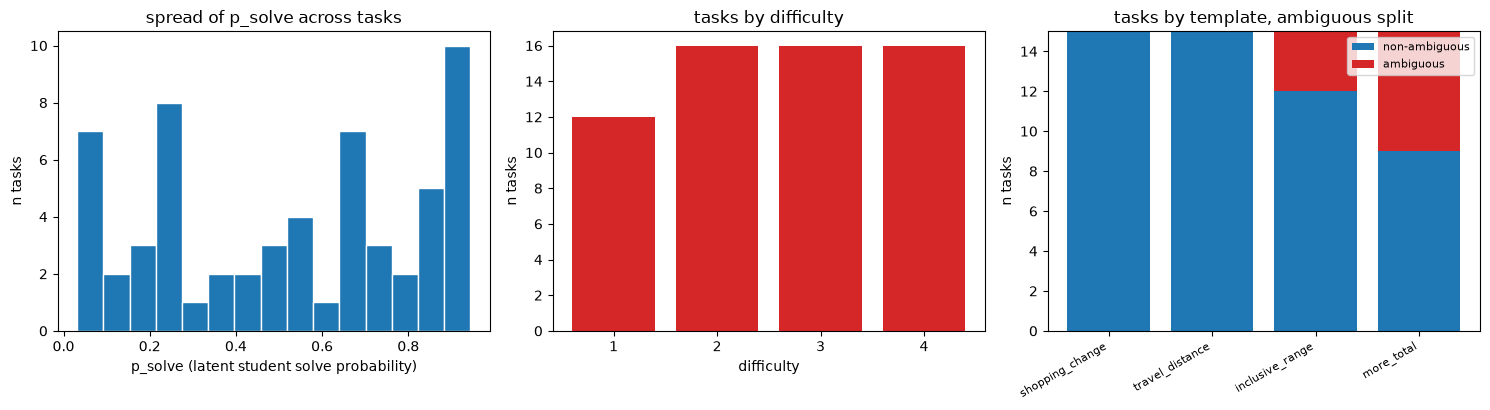

In [3]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.2))

ax1.hist(ps, bins=15, color=PALETTE["student"], edgecolor="white")
ax1.set_xlabel("p_solve (latent student solve probability)")
ax1.set_ylabel("n tasks")
ax1.set_title("spread of p_solve across tasks")

diff_counts = TASKS_DF["difficulty"].value_counts().sort_index()
ax2.bar(diff_counts.index.astype(str), diff_counts.values, color=PALETTE["human"])
ax2.set_xlabel("difficulty")
ax2.set_ylabel("n tasks")
ax2.set_title("tasks by difficulty")

templates = ["shopping_change", "travel_distance", "inclusive_range", "more_total"]
non_amb = [int(((TASKS_DF.template == t) & (~TASKS_DF.ambiguous)).sum()) for t in templates]
amb = [int(((TASKS_DF.template == t) & (TASKS_DF.ambiguous)).sum()) for t in templates]
x = np.arange(len(templates))
ax3.bar(x, non_amb, color=PALETTE["non_ambiguous"], label="non-ambiguous")
ax3.bar(x, amb, bottom=non_amb, color=PALETTE["ambiguous"], label="ambiguous")
ax3.set_xticks(x)
ax3.set_xticklabels(templates, rotation=30, ha="right", fontsize=8)
ax3.set_ylabel("n tasks")
ax3.set_title("tasks by template, ambiguous split")
ax3.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 2. Candidate responses (reasoning traces) with latent quality

> **Trace**
> - **Paper:** P1 for the on/off-policy passage; everything else belongs to no paper
> - **Result and query:** the on-policy vs off-policy distinction -- `q9`
> - **Status:** QUOTED (the `q9` passage); DERIVED HERE (feature scheme, gold quality $q^*$, student policy $\pi_0$, human policy); CHECK 2.1-2.6 are generator sanity checks

**Claim.** For each task we render 8 **on-policy student samples** plus 2 **off-policy
human-written exemplars**, each with a documented latent feature vector, a deterministic gold
quality `q*`, and (for student samples) the student policy's own log-probability of having
produced that exact feature combination -- the thing Notebook 3 needs to measure reward variance
**under the student's own samples**, per the source papers' on/off-policy distinction (`q9`):

> "The preferred and dispreferred responses can be obtained by generating two candidate responses
> from the model (i.e. on-policy)... Alternatively, they can be taken from some static dataset
> (i.e. off-policy). Our analysis and experiments capture both cases." (`q9`)

**Latent features per response** (all binary, all documented, **derived here** -- none of this
feature scheme is in the papers): `final_correct`, `reasoning_valid` (a right answer can be
reached via a wrong step -- "lucky"), `shows_steps`, `verifies_answer`, `states_units`,
`follows_style_guide_reading` (only meaningful on ambiguous tasks), `verbose`.

**Gold quality `q*` (derived here, deterministic function of the features):**
- `incorrect` (not `final_correct`) -> tier score 0.0
- `lucky_correct` (`final_correct` but not `reasoning_valid`) -> 0.30
- `great` (`final_correct` and `reasoning_valid`, but not both `verifies_answer` **and**
  `follows_style_guide_reading`) -> 0.60
- `excellent` (`final_correct`, `reasoning_valid`, `verifies_answer`, **and**
  `follows_style_guide_reading`) -> 0.90

then `q* = tier + 0.03*shows_steps + 0.02*states_units - 0.02*(verbose and not shows_steps)`,
clipped to `[0, 1]`. This is exactly the "excellent vs. great" subtlety the brief asks for
(verification + valid reasoning + the style-guide reading), and it is the kind of high-end
distinction a **coarse** rubric (`## 3`) will not capture.

**Student policy π₀ (derived here).** `(final_correct, reasoning_valid)` is drawn from a 4-way
categorical `{CC, CI, WV, WI}` with `P(CC)=0.85p, P(CI)=0.15p, P(WV)=0.25(1-p), P(WI)=0.75(1-p)`
(so the marginal `P(final_correct) = p`). For **student** samples `p` is the task's latent solve
probability `task["p_solve"]`; for **human** samples `p` is a separate `human_p_solve(task)`
(~80-90%, mildly difficulty-dependent, always well above the student's `p_solve`) -- exemplars are
vendor-quality work, not another on-policy rollout, so their correctness should not track the
student's own difficulty curve. The other four features are independent Bernoullis with fixed
probabilities that encode "the student prefers verbose, rarely verifies, and is a coin-flip on the
ambiguous-task reading" -- `verbose=0.65`, `verifies_answer=0.15`, `follows_style_guide_reading=0.40`
-- vs. the human exemplar policy's `verbose=0.30`, `verifies_answer=0.45`,
`follows_style_guide_reading=0.80` (high, but deliberately **not** 1.0: the wording is genuinely
contested even for a careful human on these tasks). Because this whole draw is a fully-specified
generative probability model, the realized log-probability of each drawn feature vector **is**
`log π₀(y|x)` for that response -- stored as `policy_logprob`, exactly the "latent logits" the
brief asks to keep for Notebook 3.

In [4]:
FEATURES = ["final_correct", "reasoning_valid", "shows_steps", "verifies_answer",
            "states_units", "follows_style_guide_reading", "verbose"]

STUDENT_POLICY_PARAMS = {"shows_steps": 0.55, "verifies_answer": 0.15, "states_units": 0.45,
                          "verbose": 0.65, "follows_style_guide_reading": 0.40}
# Human exemplars often skip explicit verification, sometimes write verbosely, and on ambiguous
# tasks follow the style-guide gold reading only ~80% of the time (not 100% -- the wording is
# genuinely contested even for a careful human, which is the whole point of calling it
# "definition-hard"). Regression fix: an earlier draft's HUMAN_POLICY_PARAMS only biased the
# *style* features (verbose/verifies/shows_steps/states_units) -- CORRECTNESS itself still came
# from `cv_probs(task["p_solve"])`, the STUDENT's own per-task solve probability, so a vendor's
# paid human exemplar was exactly as likely to be wrong as an on-policy student sample. Fixed
# below with a separate `human_p_solve(task)` that drives correctness for human rows.
HUMAN_POLICY_PARAMS = {"shows_steps": 0.90, "verifies_answer": 0.45, "states_units": 0.70,
                        "verbose": 0.30, "follows_style_guide_reading": 0.80}
UNIT_WORDS = {"dollars": "dollars", "miles": "miles", "days": "days"}


def human_p_solve(task):
    # Human-written exemplars are vendor-quality work, not a random on-policy rollout: correctness
    # stays high regardless of how hard the task is for the STUDENT policy, though the hardest
    # tasks still occasionally trip up a human annotator. Derived here -- neither the job posting
    # nor the three papers specify an exemplar accuracy; this keeps the mean around 85-90% correct
    # (weighted over TASKS' actual difficulty mix) while remaining a deterministic, documented
    # function of difficulty, in the same spirit as the q* tier function below.
    return float(np.clip(0.90 - 0.02 * (task["difficulty"] - 1), 0.80, 0.90))


def cv_probs(p):
    # (final_correct, reasoning_valid) joint. CC=correct&valid, CI=correct&invalid ("lucky"),
    # WV=wrong&valid ("clean misread"), WI=wrong&invalid ("messy"). Marginal P(correct) = p.
    return {"CC": 0.85 * p, "CI": 0.15 * p, "WV": 0.25 * (1 - p), "WI": 0.75 * (1 - p)}


def _bern_logprob(x, p):
    return np.log(p) if x else np.log(1 - p)


def sample_response_features(task, policy_params, rng, p_correct=None):
    # p_correct overrides the task's own p_solve -- used for human exemplars, whose correctness
    # is NOT the student policy's solve probability (see human_p_solve above).
    p_correct = task["p_solve"] if p_correct is None else p_correct
    cvp = cv_probs(p_correct)
    labels = list(cvp.keys())
    probs = np.array([cvp[k] for k in labels])
    probs = probs / probs.sum()
    cv = labels[rng.choice(len(labels), p=probs)]
    final_correct, reasoning_valid = cv in ("CC", "CI"), cv in ("CC", "WV")
    logp = np.log(cvp[cv])
    feats = {"final_correct": final_correct, "reasoning_valid": reasoning_valid}
    for name in ["shows_steps", "verifies_answer", "states_units", "verbose"]:
        prob = policy_params[name]
        val = bool(rng.random() < prob)
        feats[name] = val
        logp += _bern_logprob(val, prob)
    if task["ambiguous"]:
        prob = policy_params["follows_style_guide_reading"]
        val = bool(rng.random() < prob)
        feats["follows_style_guide_reading"] = val
        logp += _bern_logprob(val, prob)
    else:
        feats["follows_style_guide_reading"] = True  # vacuous: only one reading exists
    return feats, float(logp)


def _local_rng(task_id, sample_idx):
    # Deterministic RNG keyed ONLY by (task_id, sample_idx) -- NOT by `source` or which features
    # got edited. This means build_response(..., sample_idx=k) always makes the exact same
    # "which earlier step gets corrupted" choice for a given (task, k), whether it's the original
    # student/human sample or an edited_variant() of it (## 5's near-duplicate / add-verification
    # pairs). Without this, editing one feature (e.g. flipping final_correct) and re-rendering
    # from scratch would re-roll an INDEPENDENT corruption draw, breaking the minimal-edit
    # property those pair types are supposed to have.
    seed = int(hashlib.sha256(f"{task_id}_{sample_idx}".encode()).hexdigest()[:8], 16)
    return np.random.default_rng(seed)


def render_response(task, feats, displayed_answer, steps_used, sample_idx):
    unit_word = UNIT_WORDS.get(task["unit"], "")
    lrng = _local_rng(task["task_id"], sample_idx)
    lines = []
    if feats["verbose"]:
        lines.append("Let's work through this problem carefully, one part at a time.")
    if feats["shows_steps"]:
        show_steps = list(steps_used)
        if not feats["final_correct"]:
            desc0, _ = show_steps[-1]
            show_steps[-1] = (desc0, displayed_answer)  # keep last shown step == final line
        if not feats["reasoning_valid"]:
            earlier = list(range(len(show_steps) - 1))
            if earlier:
                idx = int(lrng.choice(earlier))
                desc, val = show_steps[idx]
                show_steps[idx] = (desc, val + int(lrng.choice([-2, -1, 1, 2, 3])))
            else:
                lines.append("Skipping ahead without checking each part separately:")
        for desc, val in show_steps:
            lines.append(f"For {desc}, that comes to {val}." if feats["verbose"] else f"{desc} -> {val}.")
    else:
        lines.append("Doing the arithmetic quickly gives an answer." if not feats["reasoning_valid"]
                      else "Working through the numbers gives an answer.")
    ans_str = f"{displayed_answer} {unit_word}".strip() if (feats["states_units"] and unit_word) else str(displayed_answer)
    lines.append(f"So, putting it all together, the final answer comes out to {ans_str}." if feats["verbose"]
                 else f"Answer: {ans_str}.")
    if feats["verifies_answer"]:
        lines.append(f"Double-checking the arithmetic again confirms {ans_str} is correct." if feats["verbose"]
                     else f"Checking again confirms {ans_str}.")
    return " ".join(lines)


def build_response(task, feats, logp, source, sample_idx):
    ambiguous = task["ambiguous"]
    reading_used = "gold" if (not ambiguous or feats["follows_style_guide_reading"]) else "alt"
    target = task["answer_gold"] if reading_used == "gold" else task["answer_alt"]
    displayed_answer = target if feats["final_correct"] else task["distractor_answer"]
    matches_gold_answer = (displayed_answer == task["answer_gold"])
    steps_used = task["steps_gold"] if reading_used == "gold" else task["steps_alt"]
    text = render_response(task, feats, displayed_answer, steps_used, sample_idx)

    if not feats["final_correct"]:
        tier, score = "incorrect", 0.0
    elif not feats["reasoning_valid"]:
        tier, score = "lucky_correct", 0.30
    elif feats["verifies_answer"] and feats["follows_style_guide_reading"]:
        tier, score = "excellent", 0.90
    else:
        tier, score = "great", 0.60
    q_star = float(np.clip(score + 0.03 * feats["shows_steps"] + 0.02 * feats["states_units"]
                            - 0.02 * (feats["verbose"] and not feats["shows_steps"]), 0.0, 1.0))
    return {"response_id": f"{task['task_id']}_{source}_{sample_idx}", "task_id": task["task_id"],
            "source": source, "sample_idx": sample_idx, **feats, "reading_used": reading_used,
            "displayed_answer": displayed_answer, "matches_gold_answer": matches_gold_answer,
            "tier": tier, "q_star": q_star, "policy_logprob": logp, "text": text,
            "n_words": len(text.split())}


def build_responses(tasks):
    rng = np.random.default_rng(SEED + 3)
    rows = []
    for task in tasks:
        for i in range(8):
            feats, logp = sample_response_features(task, STUDENT_POLICY_PARAMS, rng)
            rows.append(build_response(task, feats, logp, "student", i))
        for i in range(2):
            feats, logp = sample_response_features(task, HUMAN_POLICY_PARAMS, rng, p_correct=human_p_solve(task))
            rows.append(build_response(task, feats, logp, "human", i))
    return rows


RESPONSES = build_responses(TASKS)
RESPONSES_BY_TASK = {}
for r in RESPONSES:
    RESPONSES_BY_TASK.setdefault(r["task_id"], []).append(r)
RESPONSES_DF = pd.DataFrame(RESPONSES)

print(f"[CHECK 2.1] n responses = {len(RESPONSES)} (expect 60*10=600): "
      f"{'PASS' if len(RESPONSES) == 600 else 'FAIL'}")
words = RESPONSES_DF["n_words"].to_numpy()
print(f"[CHECK 2.2] response length: min={words.min()} mean={words.mean():.1f} max={words.max()} words "
      f"(target <= ~90): {'PASS' if words.max() <= 90 else 'FAIL'}")

# internal-consistency self-check: the last number stated in the text must equal displayed_answer
_bad = 0
for r in RESPONSES:
    nums = re.findall(r"(-?\d+)", r["text"])
    if not nums or int(nums[-1]) != r["displayed_answer"]:
        _bad += 1
print(f"[CHECK 2.3] responses whose stated final number != displayed_answer: {_bad}/600 "
      f"({'PASS' if _bad == 0 else 'FAIL'})")

corr_df = RESPONSES_DF[RESPONSES_DF.source == "student"].merge(
    TASKS_DF[["task_id", "p_solve"]], on="task_id")
per_task = corr_df.groupby("task_id").agg(emp=("final_correct", "mean"), p=("p_solve", "first"))
corr = float(np.corrcoef(per_task["emp"], per_task["p"])[0, 1])
print(f"[CHECK 2.4] corr(empirical student correctness rate, task p_solve) across tasks = {corr:.3f} "
      f"(expect strongly positive): {'PASS' if corr > 0.6 else 'FAIL'}")

print(f"[CHECK 2.5] tier counts: {dict(RESPONSES_DF['tier'].value_counts())}")
q_star_student = float(RESPONSES_DF.loc[RESPONSES_DF.source == "student", "q_star"].mean())
q_star_human = float(RESPONSES_DF.loc[RESPONSES_DF.source == "human", "q_star"].mean())
human_final_correct_rate = float(RESPONSES_DF.loc[RESPONSES_DF.source == "human", "final_correct"].mean())
q_star_gap = q_star_human - q_star_student
check_26 = (human_final_correct_rate >= 0.80) and (q_star_gap >= 0.15)
print(f"[CHECK 2.6] mean q_star -- student={q_star_student:.3f} human={q_star_human:.3f} (gap={q_star_gap:+.3f}); "
      f"human final-correct rate={human_final_correct_rate:.3f} "
      f"(spec: human final-correct rate >= 0.80 AND q_star gap >= 0.15, so exemplars are genuinely, "
      f"not just marginally, higher quality): {'PASS' if check_26 else 'FAIL'}")

RESPONSES_DF.drop(columns=["text"]).to_json(NB2_DIR / "responses_meta.json", orient="records", indent=2)
RESPONSES_DF[["response_id", "text"]].to_json(NB2_DIR / "responses_text.json", orient="records", indent=2)
print(f"wrote {NB2_DIR / 'responses_meta.json'} and responses_text.json")

_ex = RESPONSES[0]
print("--- example response ---", _ex["response_id"], _ex["tier"])
print(_ex["text"])

[CHECK 2.1] n responses = 600 (expect 60*10=600): PASS
[CHECK 2.2] response length: min=9 mean=32.0 max=72 words (target <= ~90): PASS
[CHECK 2.3] responses whose stated final number != displayed_answer: 0/600 (PASS)
[CHECK 2.4] corr(empirical student correctness rate, task p_solve) across tasks = 0.919 (expect strongly positive): PASS
[CHECK 2.5] tier counts: {'great': np.int64(244), 'incorrect': np.int64(241), 'excellent': np.int64(61), 'lucky_correct': np.int64(54)}
[CHECK 2.6] mean q_star -- student=0.335 human=0.595 (gap=+0.259); human final-correct rate=0.867 (spec: human final-correct rate >= 0.80 AND q_star gap >= 0.15, so exemplars are genuinely, not just marginally, higher quality): PASS
wrote /home/centos/data/projects/for-money/computer-science/upwork/flex-projects/alignment-post-training/data/nb2/responses_meta.json and responses_text.json
--- example response --- T001_student_0 great
2 rulers x $4 -> 8. 5 folders x $2 -> 10. total $18, paid with a $45 bill -> 27. Answer: 

#### How to read this chart

> **Trace**
> - **Paper:** none
> - **Result and query:** generator diagnostic (CHECK 2.6 gates the human-vs-student gap)
> - **Status:** DERIVED HERE; no paper claim is tested by this chart

Left: `q*` histogram, split by `source` (student on-policy vs. human off-policy exemplars) -- the
human distribution should sit visibly to the right of the student one, since human correctness is
driven by the separate, high `human_p_solve(task)` (not the task's own `p_solve`, see `## 2`
above) on top of the human policy's better verification/style-guide-adherence rates; CHECK 2.6
requires this gap to be large (>= 0.15 in mean `q*`), not just directionally correct. Middle: tier
counts (`incorrect`, `lucky_correct`, `great`, `excellent`) stacked by source -- humans should
concentrate in `great`/`excellent`, students should have a large `incorrect` mass. Right: for
ambiguous tasks only, the fraction of student vs. human responses that follow the style-guide gold
reading -- humans track it noticeably more often than students (`~80%` vs. `~40%` by construction),
but **not** at 100%: that gap-but-not-certainty is the direct, checkable illustration of "ambiguous
items are definition-hard, not just hard" -- even careful humans get the contested reading wrong
sometimes.


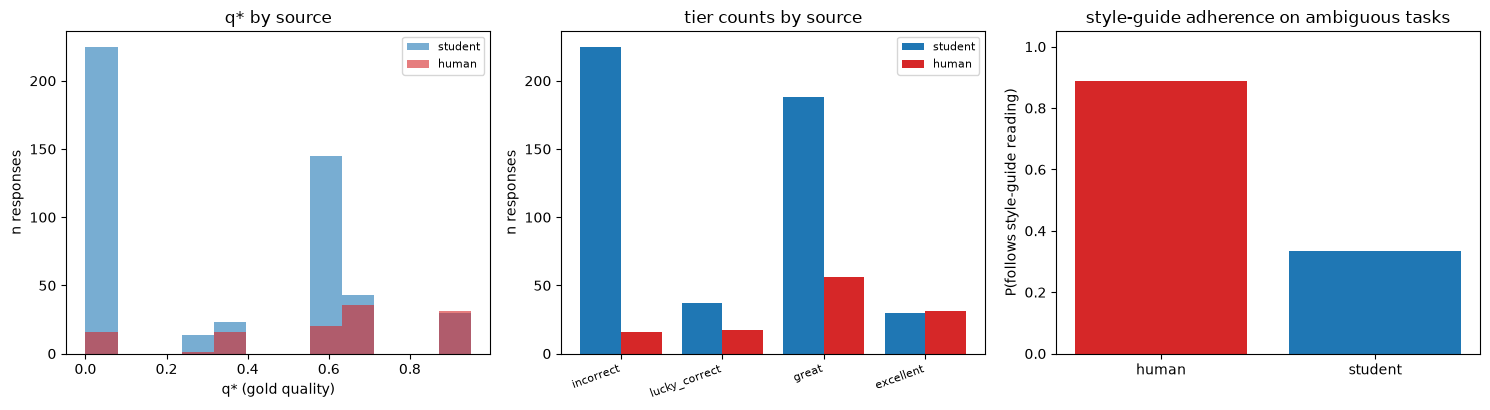

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.2))

for src, color in [("student", PALETTE["student"]), ("human", PALETTE["human"])]:
    vals = RESPONSES_DF.loc[RESPONSES_DF.source == src, "q_star"]
    ax1.hist(vals, bins=12, alpha=0.6, label=src, color=color)
ax1.set_xlabel("q* (gold quality)")
ax1.set_ylabel("n responses")
ax1.set_title("q* by source")
ax1.legend(fontsize=8)

tier_order = ["incorrect", "lucky_correct", "great", "excellent"]
pivot = RESPONSES_DF.pivot_table(index="tier", columns="source", values="response_id",
                                  aggfunc="count", fill_value=0).reindex(tier_order)
x = np.arange(len(tier_order))
ax2.bar(x - 0.2, pivot["student"], width=0.4, label="student", color=PALETTE["student"])
ax2.bar(x + 0.2, pivot["human"], width=0.4, label="human", color=PALETTE["human"])
ax2.set_xticks(x)
ax2.set_xticklabels(tier_order, rotation=20, ha="right", fontsize=8)
ax2.set_ylabel("n responses")
ax2.set_title("tier counts by source")
ax2.legend(fontsize=8)

amb_resp = RESPONSES_DF[RESPONSES_DF.task_id.isin(TASKS_DF.loc[TASKS_DF.ambiguous, "task_id"])]
rate = amb_resp.groupby("source")["follows_style_guide_reading"].mean()
# Colors keyed by rate.index (alphabetical: "human" before "student"), not a hardcoded
# [student, human] list -- that mismatch previously painted the wrong color under each bar.
ax3.bar(rate.index, rate.values, color=[PALETTE[s] for s in rate.index])
ax3.set_ylim(0, 1.05)
ax3.set_ylabel("P(follows style-guide reading)")
ax3.set_title("style-guide adherence on ambiguous tasks")

fig.tight_layout()
plt.show()

## 3. The client's rubrics and a simulated verifier

> **Trace**
> - **Paper:** P3
> - **Result and query:** rubric reward formula $r=\sum_i w_iV(x,y,c_i)/\sum_i w_i$, Principle 1 and Principle 2, the Table 2 tie convention -- `q7`
> - **Status:** QUOTED (formula, principles, convention); DERIVED HERE (criteria bank, error rates, coarse vs sharp rubrics, the $K=5$ noisy verifier); CHECK 3.1-3.6 are simulator sanity checks

**Claim.** We replicate the rubric-reward formula from Paper 3 exactly, quoted verbatim (`q7`):

> "the verifier outputs a binary score for each criterion, `V(x, y, cᵢ) ↦ {0, 1}`, and the total
> reward is: `r(x,y) = Σᵢ wᵢ V(x,y,cᵢ) / Σᵢ wᵢ`" (`q7`)

and the two rubric-construction principles that motivate the coarse-vs-sharp split below (`q7`):

> "[Principle 1] Effective rubric construction requires distinguishing excellent responses from
> great ones. [Principle 2] Effective rubric construction requires distinguishing among diverse
> off-policy responses." (`q7`)

**Criteria bank** (`derived here` -- the specific criteria and error rates are this project's
design, not the paper's): 8 binary criteria, each with a latent verifier error rate --
**objective** criteria (`states_final_answer`, `final_answer_correct`, `states_units`) get low
error (0.03-0.07), **judgment** criteria (`checks_result`, `uses_style_guide_reading`, `concise`,
`reasoning_rigorous`) get higher error (0.15-0.25). Every task gets a rubric of 4-6 weighted
criteria in one of two styles:

- **coarse**: `states_final_answer`, `final_answer_correct`, `shows_steps`, `states_units`,
  `concise` -- the kind of rubric where a `great` and an `excellent` response (`## 2`) can tie,
  because coarse rubrics never check `checks_result` or `uses_style_guide_reading`.
- **sharp**: adds `checks_result`, `reasoning_rigorous`, and (on ambiguous tasks)
  `uses_style_guide_reading` -- the high-end distinctions Principle 1/2 call for.

Each response is graded `K=5` times independently (a noisy verifier flips the ground-truth
criterion value with probability = that criterion's error rate), and we store the majority vote.
Paper 3's Table 2 convention, quoted verbatim (`q7`):

> "Rubric preferences were determined by a majority vote from five independent gradings, with
> ties counted as incorrect." (`q7`)

is kept available here (majority of 5 per criterion cannot itself tie, since 5 is odd) so Notebook
3's pairwise tail-accuracy computation, where ties over a *pair* of responses are possible, can
reuse the same convention.

In [6]:
CRITERION_ERROR_RATE = {
    "states_final_answer": 0.03, "final_answer_correct": 0.05, "shows_steps": 0.07,
    "states_units": 0.05, "checks_result": 0.15, "uses_style_guide_reading": 0.20,
    "concise": 0.18, "reasoning_rigorous": 0.25,
}
CRITERION_KIND = {
    "states_final_answer": "objective", "final_answer_correct": "objective",
    "shows_steps": "semi-objective", "states_units": "objective",
    "checks_result": "judgment", "uses_style_guide_reading": "judgment",
    "concise": "judgment", "reasoning_rigorous": "judgment",
}
CRITERION_DESC = {
    "states_final_answer": "The response clearly states a final numeric answer.",
    "final_answer_correct": "The response's final numeric answer is correct.",
    "shows_steps": "The response shows its step-by-step work, not just a bare final number.",
    "checks_result": "The response explicitly checks or verifies its own final answer.",
    "states_units": "The response states its final answer with the correct units.",
    "uses_style_guide_reading": "The response's interpretation of the wording matches the style guide's designated (gold) reading.",
    "concise": "The response is concise, without unnecessary filler sentences.",
    "reasoning_rigorous": "The response's reasoning is rigorous and logically valid, not a correct number reached by a flawed or skipped step.",
}
K_GRADINGS = 5


def criterion_truth(name, task, resp):
    if name == "states_final_answer":
        return True
    if name == "final_answer_correct":
        return bool(resp["matches_gold_answer"])
    if name == "shows_steps":
        return bool(resp["shows_steps"])
    if name == "checks_result":
        return bool(resp["verifies_answer"])
    if name == "states_units":
        return True if task["unit"] is None else bool(resp["states_units"])
    if name == "uses_style_guide_reading":
        return True if not task["ambiguous"] else bool(resp["follows_style_guide_reading"])
    if name == "concise":
        return not bool(resp["verbose"])
    if name == "reasoning_rigorous":
        return bool(resp["reasoning_valid"])
    raise ValueError(name)


def build_rubric(task, style, rng):
    base = ["states_final_answer", "final_answer_correct"]
    if style == "coarse":
        cands = ["shows_steps", "states_units", "concise"]
        if task["unit"] is None:
            cands = [c for c in cands if c != "states_units"]
        criteria = base + cands
    else:
        extra = ["shows_steps", "checks_result", "reasoning_rigorous"]
        if task["ambiguous"]:
            extra = extra + ["uses_style_guide_reading"]
        criteria = base + extra
    weights = {c: float(rng.integers(1, 4)) for c in criteria}
    return criteria, weights


def build_rubrics(tasks):
    rng = np.random.default_rng(SEED + 4)
    rows = []
    for task in tasks:
        style = "coarse" if rng.random() < 0.5 else "sharp"
        criteria, weights = build_rubric(task, style, rng)
        for c in criteria:
            rows.append({"task_id": task["task_id"], "style": style, "criterion": c,
                         "weight": weights[c], "error_rate": CRITERION_ERROR_RATE[c],
                         "kind": CRITERION_KIND[c]})
    return pd.DataFrame(rows)


def simulate_gradings(tasks, responses, rubrics_df):
    task_by_id = {t["task_id"]: t for t in tasks}
    rng = np.random.default_rng(SEED + 5)
    grading_rows, reward_rows = [], []
    rubric_by_task = {tid: g for tid, g in rubrics_df.groupby("task_id")}
    for resp in responses:
        task = task_by_id[resp["task_id"]]
        rub = rubric_by_task[resp["task_id"]]
        criteria = rub["criterion"].tolist()
        weights = dict(zip(rub["criterion"], rub["weight"]))
        style = rub["style"].iloc[0]
        w_sum = sum(weights.values())
        truths = {c: criterion_truth(c, task, resp) for c in criteria}
        true_reward = sum(weights[c] * truths[c] for c in criteria) / w_sum
        majority = {}
        for c in criteria:
            err = CRITERION_ERROR_RATE[c]
            votes = []
            for k in range(K_GRADINGS):
                flip = rng.random() < err
                grade = (not truths[c]) if flip else truths[c]
                votes.append(grade)
                grading_rows.append({"response_id": resp["response_id"], "task_id": resp["task_id"],
                                      "criterion": c, "run": k, "grade": grade, "truth": truths[c],
                                      "style": style})
            majority[c] = (sum(votes) >= 3)
        maj_reward = sum(weights[c] * majority[c] for c in criteria) / w_sum
        reward_rows.append({"response_id": resp["response_id"], "task_id": resp["task_id"], "style": style,
                             "true_reward": true_reward, "majority_reward": maj_reward,
                             "q_star": resp["q_star"], "tier": resp["tier"]})
    return pd.DataFrame(grading_rows), pd.DataFrame(reward_rows)


RUBRICS_DF = build_rubrics(TASKS)
GRADINGS_DF, REWARDS_DF = simulate_gradings(TASKS, RESPONSES, RUBRICS_DF)

n_crit = RUBRICS_DF.groupby("task_id").size()
print(f"[CHECK 3.1] criteria per task: min={n_crit.min()} max={n_crit.max()} "
      f"(spec: 4-6): {'PASS' if 4 <= n_crit.min() and n_crit.max() <= 6 else 'FAIL'}")
print(f"[CHECK 3.2] rubric style counts: {dict(RUBRICS_DF.groupby('task_id')['style'].first().value_counts())}")
print(f"[CHECK 3.3] gradings rows = {len(GRADINGS_DF)} "
      f"(expect 600 responses * ~5 criteria * 5 runs): {'PASS' if len(GRADINGS_DF) > 10000 else 'FAIL'}")
overall_agree = (GRADINGS_DF["grade"] == GRADINGS_DF["truth"]).mean()
print(f"[CHECK 3.4] overall per-grading agreement with latent truth = {overall_agree:.3f} "
      f"(objective criteria should be higher than judgment): "
      f"{'PASS' if 0.80 < overall_agree < 0.99 else 'FAIL'}")
per_crit_agree = GRADINGS_DF.groupby("criterion").apply(lambda d: (d["grade"] == d["truth"]).mean())
print("[CHECK 3.5] per-criterion agreement:")
print(per_crit_agree.sort_values())
print(f"[CHECK 3.6] mean true_reward by tier (expect monotone incorrect<lucky<great<excellent): "
      f"{dict(REWARDS_DF.groupby('tier')['true_reward'].mean().round(3))}")

RUBRICS_DF.to_json(NB2_DIR / "rubrics.json", orient="records", indent=2)
REWARDS_DF.to_json(NB2_DIR / "rewards.json", orient="records", indent=2)
GRADINGS_DF.to_json(NB2_DIR / "gradings.json", orient="records", indent=2)
print(f"wrote rubrics.json, rewards.json, gradings.json to {NB2_DIR}")

[CHECK 3.1] criteria per task: min=4 max=6 (spec: 4-6): PASS
[CHECK 3.2] rubric style counts: {'sharp': np.int64(30), 'coarse': np.int64(30)}
[CHECK 3.3] gradings rows = 14900 (expect 600 responses * ~5 criteria * 5 runs): PASS
[CHECK 3.4] overall per-grading agreement with latent truth = 0.908 (objective criteria should be higher than judgment): PASS
[CHECK 3.5] per-criterion agreement:
criterion
reasoning_rigorous          0.769333
concise                     0.818667
uses_style_guide_reading    0.833333
checks_result               0.860667
shows_steps                 0.938333
final_answer_correct        0.948667
states_units                0.949091
states_final_answer         0.968000
dtype: float64
[CHECK 3.6] mean true_reward by tier (expect monotone incorrect<lucky<great<excellent): {'excellent': np.float64(0.854), 'great': np.float64(0.686), 'incorrect': np.float64(0.445), 'lucky_correct': np.float64(0.639)}
wrote rubrics.json, rewards.json, gradings.json to /home/centos/data/pr

#### How to read this chart

> **Trace**
> - **Paper:** P3 for the formula being plotted; coarse vs sharp is our proxy for its Principle 1
> - **Result and query:** the rubric reward formula -- `q7`
> - **Status:** DERIVED HERE (all plotted numbers come from the simulated verifier)

Left: mean `majority_reward` by tier (`incorrect`/`lucky_correct`/`great`/`excellent`), split
coarse vs. sharp -- watch specifically whether the coarse bars for `great` and `excellent` sit
close together (a tie-prone rubric) while the sharp bars separate them more. Middle: per-criterion
agreement rate between the simulated noisy verifier and latent truth, sorted low to high --
judgment criteria (`reasoning_rigorous`, `concise`, `uses_style_guide_reading`, `checks_result`)
should sit visibly below the objective ones. Right: `true_reward` vs. `majority_reward` scatter
(a sample of 150 responses) -- points far from the diagonal are cases where 5 noisy gradings
disagree with what a perfect verifier would have said.

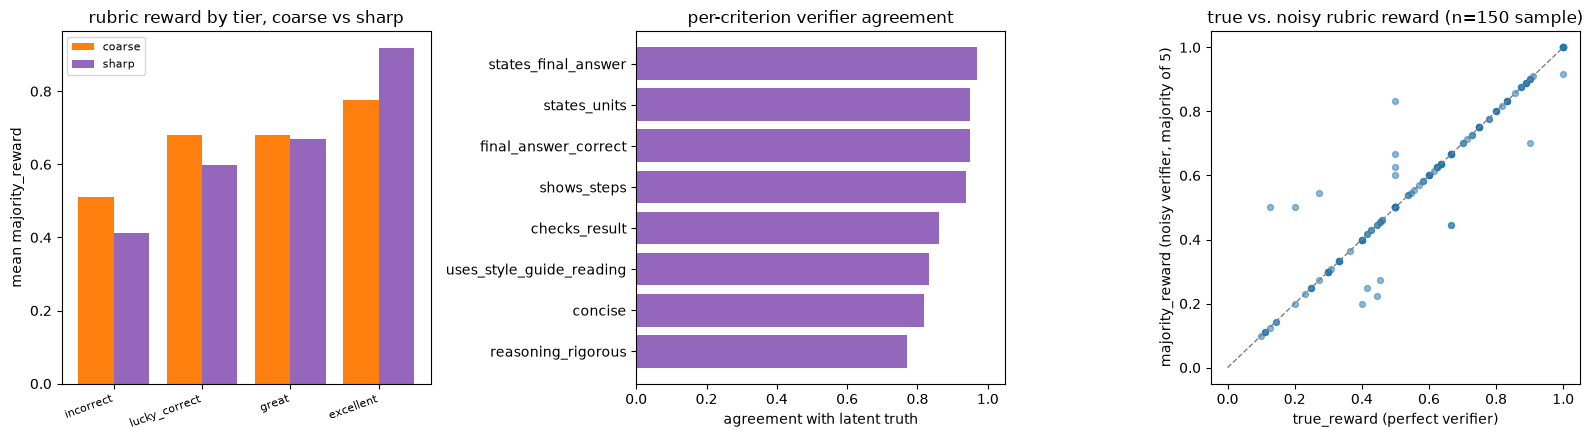

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.5))

tier_order = ["incorrect", "lucky_correct", "great", "excellent"]
piv = REWARDS_DF.pivot_table(index="tier", columns="style", values="majority_reward", aggfunc="mean").reindex(tier_order)
x = np.arange(len(tier_order))
ax1.bar(x - 0.2, piv["coarse"], width=0.4, label="coarse", color=PALETTE["coarse"])
ax1.bar(x + 0.2, piv["sharp"], width=0.4, label="sharp", color=PALETTE["sharp"])
ax1.set_xticks(x)
ax1.set_xticklabels(tier_order, rotation=20, ha="right", fontsize=8)
ax1.set_ylabel("mean majority_reward")
ax1.set_title("rubric reward by tier, coarse vs sharp")
ax1.legend(fontsize=8)

order = per_crit_agree.sort_values()
ax2.barh(order.index, order.values, color=PALETTE["sharp"])
ax2.set_xlabel("agreement with latent truth")
ax2.set_title("per-criterion verifier agreement")
ax2.set_xlim(0, 1.05)

samp = REWARDS_DF.sample(n=150, random_state=SEED)
ax3.scatter(samp["true_reward"], samp["majority_reward"], alpha=0.5, s=18, color=PALETTE["student"])
ax3.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
ax3.set_xlabel("true_reward (perfect verifier)")
ax3.set_ylabel("majority_reward (noisy verifier, majority of 5)")
ax3.set_title("true vs. noisy rubric reward (n=150 sample)")

fig.tight_layout()
plt.show()

## 4. Real LLM verifier smoke test (DeepSeek), capped and cached

> **Trace**
> - **Paper:** P3
> - **Result and query:** the proposer, verifier and policy models (GPT-4.1, GPT-4.1-mini, Qwen3-8B-Base) -- `q7`
> - **Status:** QUOTED (model names); DERIVED HERE (DeepSeek as a budget substitute, the 24-call stratified sample); the endpoint, request body and pricing come from own testing, not from any paper; CHECK 4.1-4.6

**Claim.** Paper 3's own verifier is an LLM, quoted verbatim (`q7`):

> "GPT-4.1" as the rubric proposer... "GPT-4.1-mini" as the rubric verifier... "Qwen3-8B-Base" as
> the base policy model (`q7`)

so a real LLM verifier smoke test is directly justified by the source material -- `## 3`'s
simulated verifier stands in for exactly this role, and this section checks how a **real** (much
cheaper) LLM verifier -- DeepSeek `deepseek-flash`, not GPT-4.1-mini, a **substitution made here
for budget reasons, not the paper's model** -- agrees with the corpus's latent truth on a small,
capped, cached sample. This is explicitly a **smoke test**, not a claim that 24 calls validate a
verifier at scale (see `## 8`).

**Sample.** A stratified sample of **24** `(response, criterion)` pairs: 6 `uses_style_guide_reading`
pairs on ambiguous tasks, 6 judgment-criterion pairs (`checks_result`/`reasoning_rigorous`/`concise`),
6 objective-criterion pairs, and 6 drawn from the full pool for general coverage -- so the smoke
test isn't just grading the easy cases. `MAX_LIVE_CALLS = 24` so a re-run can never exceed 24 new
calls, and the client is disk-cached by request-body hash (adapted from the proven cached client in
`flex-projects/nlp-job/notebooks/02_project_walkthrough_part1.ipynb`, cell 11).

**Verified request/response facts (my own testing today, not from the papers):** endpoint
`POST https://api.deepseek.com/chat/completions`; body
`{"model":"deepseek-flash","messages":[...],"max_tokens":2,"temperature":0,"thinking":{"type":"disabled"}}`
answered `'YES'`; `usage` contains `prompt_tokens`, `completion_tokens`, `prompt_cache_hit_tokens`,
`prompt_cache_miss_tokens`. Pricing (`in_hit 0.006 / in_miss 0.30 / out 1.20` USD per 1M tokens,
peak) is **"as used in the reference project, not re-verified"** here.

In [8]:
DEEPSEEK_URL = "https://api.deepseek.com/chat/completions"
MODEL = "deepseek-flash"
MAX_LIVE_CALLS = 24  # a re-run can never exceed 24 new live calls -- the smoke-test budget

_STATS_LOCK = threading.Lock()


class LiveCallBudgetExceeded(RuntimeError):
    pass


class MissingAPIKey(RuntimeError):
    pass


LLM_STATS = {"live_calls": 0, "cache_hits": 0, "prompt_cache_hit_tokens": 0,
             "prompt_cache_miss_tokens": 0, "completion_tokens": 0, "http_retries": 0,
             "cached_completion_tokens": 0}
USAGE_LEDGER = []
USED_CACHE_KEYS = set()


def _find_dotenv_key():
    for d in [NOTEBOOK_DIR] + list(NOTEBOOK_DIR.parents):
        candidate = d / ".env"
        if candidate.exists():
            for line in candidate.read_text().splitlines():
                if line.startswith("DEEPSEEK_KEY="):
                    return line.split("=", 1)[1].strip()
    return None


def _get_api_key():
    return os.environ.get("DEEPSEEK_KEY") or _find_dotenv_key()


def _cache_key(body):
    payload = json.dumps(body, sort_keys=True, ensure_ascii=False)
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def _cache_path(key):
    return CACHE_DIR / key[:2] / f"{key}.json"


def deepseek_chat(body: dict, section: str = "unspecified", kind: str = "batch") -> dict:
    key = _cache_key(body)
    path = _cache_path(key)
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            cached = json.load(f)
        resp = cached["response"]
        usage = resp.get("usage", {})
        with _STATS_LOCK:
            LLM_STATS["cache_hits"] += 1
            LLM_STATS["cached_completion_tokens"] += usage.get("completion_tokens", 0)
            USAGE_LEDGER.append({"section": section, "kind": kind, "cache_hit": True, "usage": usage})
            USED_CACHE_KEYS.add(key)
        return resp

    with _STATS_LOCK:
        if LLM_STATS["live_calls"] >= MAX_LIVE_CALLS:
            raise LiveCallBudgetExceeded(f"MAX_LIVE_CALLS ({MAX_LIVE_CALLS}) exceeded.")
    api_key = _get_api_key()
    if api_key is None:
        raise MissingAPIKey("DEEPSEEK_KEY not found and this request is a cache miss.")

    data = json.dumps(body).encode("utf-8")
    req = urllib.request.Request(DEEPSEEK_URL, data=data, method="POST",
                                  headers={"Content-Type": "application/json",
                                           "Authorization": f"Bearer {api_key}"})
    delays = [1, 2, 4, 8]
    last_err = None
    for attempt in range(4):
        try:
            with urllib.request.urlopen(req, timeout=120) as f:
                resp = json.loads(f.read().decode("utf-8"))
            usage = resp.get("usage", {})
            with _STATS_LOCK:
                LLM_STATS["live_calls"] += 1
                LLM_STATS["prompt_cache_hit_tokens"] += usage.get("prompt_cache_hit_tokens", 0)
                LLM_STATS["prompt_cache_miss_tokens"] += usage.get("prompt_cache_miss_tokens", 0)
                LLM_STATS["completion_tokens"] += usage.get("completion_tokens", 0)
                USAGE_LEDGER.append({"section": section, "kind": kind, "cache_hit": False, "usage": usage})
                USED_CACHE_KEYS.add(key)
            tmp_path = path.with_suffix(f".{threading.get_ident()}.tmp")
            path.parent.mkdir(parents=True, exist_ok=True)
            with open(tmp_path, "w", encoding="utf-8") as f:
                json.dump({"request": body, "response": resp}, f)
            os.replace(tmp_path, path)
            return resp
        except (urllib.error.URLError, urllib.error.HTTPError) as e:
            last_err = e
            code_ = getattr(e, "code", None)
            if code_ is not None and code_ != 429 and not (500 <= code_ < 600):
                raise
            with _STATS_LOCK:
                LLM_STATS["http_retries"] += 1
            if attempt < 3:
                time.sleep(delays[attempt])
    raise RuntimeError(f"DeepSeek call failed after 4 attempts: {last_err}")


def llm_cost_usd(stats, peak=True):
    in_hit, in_miss, out = (0.006, 0.30, 1.20) if peak else (0.003, 0.15, 0.60)
    return (stats["prompt_cache_hit_tokens"] / 1e6 * in_hit
            + stats["prompt_cache_miss_tokens"] / 1e6 * in_miss
            + stats["completion_tokens"] / 1e6 * out)


def ledger_cost_usd(entries, peak=True):
    in_hit, in_miss, out = (0.006, 0.30, 1.20) if peak else (0.003, 0.15, 0.60)
    total = 0.0
    for e in entries:
        u = e.get("usage", {})
        total += (u.get("prompt_cache_hit_tokens", 0) / 1e6 * in_hit
                  + u.get("prompt_cache_miss_tokens", 0) / 1e6 * in_miss
                  + u.get("completion_tokens", 0) / 1e6 * out)
    return total


print("DeepSeek client defined. API key present:", _get_api_key() is not None)

DeepSeek client defined. API key present: True


In [9]:
def style_guide_note(task):
    if task["ambiguity_type"] == "inclusive_exclusive":
        return ("Style guide: when a range like 'day A through day B' is given, count "
                "INCLUSIVELY (both endpoints count).")
    if task["ambiguity_type"] == "more_total":
        return ("Style guide: 'how many more X did A do than B' means comparing the TOTAL "
                "across ALL days combined, not just the last day.")
    return ""


def make_grading_prompt(task, resp, criterion):
    note = style_guide_note(task)
    sys_msg = ("You are grading a student's math word-problem solution against ONE specific "
               "criterion. Answer with exactly one word: YES or NO. No punctuation, no explanation.")
    user_msg = (f"Problem: {task['problem_text']}\n"
                + (f"{note}\n" if note else "")
                + f"Student response: {resp['text']}\n"
                f"Criterion: {CRITERION_DESC[criterion]}\n"
                "Does the response satisfy this criterion? Answer YES or NO only.")
    return sys_msg, user_msg


def build_smoke_pool(tasks, responses, rubrics_df):
    task_by_id = {t["task_id"]: t for t in tasks}
    judgment = ["checks_result", "reasoning_rigorous", "concise"]  # list, not set: deterministic order
    objective = ["states_final_answer", "final_answer_correct", "states_units"]
    amb_task_ids = set(rubrics_df.loc[rubrics_df.task_id.isin(
        [t["task_id"] for t in tasks if t["ambiguous"]]), "task_id"])
    style_pairs = [(r["response_id"], "uses_style_guide_reading") for r in responses
                   if task_by_id[r["task_id"]]["ambiguous"]]
    judgment_pairs = [(r["response_id"], c) for r in responses for c in judgment]
    objective_pairs = [(r["response_id"], c) for r in responses for c in objective]
    all_pairs = [(r["response_id"], c) for r in responses for c in CRITERION_ERROR_RATE]
    return style_pairs, judgment_pairs, objective_pairs, all_pairs


rng_smoke = np.random.default_rng(SEED + 7)
style_pairs, judgment_pairs, objective_pairs, all_pairs = build_smoke_pool(TASKS, RESPONSES, RUBRICS_DF)


def sample_distinct(pool, n, rng, exclude):
    pool = [p for p in pool if p not in exclude]
    idx = rng.choice(len(pool), size=min(n, len(pool)), replace=False)
    picked = [pool[i] for i in idx]
    exclude.update(picked)
    return picked


chosen = set()
SMOKE_SAMPLE = []
SMOKE_SAMPLE += sample_distinct(style_pairs, 6, rng_smoke, chosen)
SMOKE_SAMPLE += sample_distinct(judgment_pairs, 6, rng_smoke, chosen)
SMOKE_SAMPLE += sample_distinct(objective_pairs, 6, rng_smoke, chosen)
SMOKE_SAMPLE += sample_distinct(all_pairs, 6, rng_smoke, chosen)

print(f"[CHECK 4.1] smoke sample size = {len(SMOKE_SAMPLE)} (spec: at most 24 live calls): "
      f"{'PASS' if len(SMOKE_SAMPLE) <= 24 else 'FAIL'}")
strat_counts = Counter()
resp_by_id = {r["response_id"]: r for r in RESPONSES}
for rid, crit in SMOKE_SAMPLE:
    t = TASKS_BY_ID[resp_by_id[rid]["task_id"]]
    strat_counts["ambiguous_task" if t["ambiguous"] else "non_ambiguous_task"] += 1
    strat_counts[CRITERION_KIND[crit]] += 1
print(f"[CHECK 4.2] stratification counts: {dict(strat_counts)} "
      f"(expect >0 ambiguous_task and >0 judgment): "
      f"{'PASS' if strat_counts['ambiguous_task'] > 0 and strat_counts['judgment'] > 0 else 'FAIL'}")

SMOKE_RESULTS = []
for rid, crit in SMOKE_SAMPLE:
    resp = resp_by_id[rid]
    task = TASKS_BY_ID[resp["task_id"]]
    sys_msg, user_msg = make_grading_prompt(task, resp, crit)
    body = {"model": MODEL,
            "messages": [{"role": "system", "content": sys_msg}, {"role": "user", "content": user_msg}],
            "max_tokens": 2, "temperature": 0, "thinking": {"type": "disabled"}}
    result = deepseek_chat(body, section="section4_smoke_test", kind=f"grade:{crit}")
    content = result["choices"][0]["message"]["content"].strip().upper()
    deepseek_yes = content.startswith("Y")
    truth = criterion_truth(crit, task, resp)
    SMOKE_RESULTS.append({"response_id": rid, "criterion": crit, "deepseek_raw": content,
                          "deepseek_yes": deepseek_yes, "truth": truth,
                          "ambiguous": task["ambiguous"], "kind": CRITERION_KIND[crit]})

SMOKE_DF = pd.DataFrame(SMOKE_RESULTS)
n_agree = int((SMOKE_DF["deepseek_yes"] == SMOKE_DF["truth"]).sum())
n_total = len(SMOKE_DF)
lo, hi = wilson_ci(n_agree, n_total)
print(f"[CHECK 4.3] DeepSeek vs. latent truth agreement (SMALL-N smoke test): "
      f"{n_agree}/{n_total} = {n_agree/n_total:.3f}, Wilson 95% CI {fmt_ci((lo, hi))}")
print(f"[CHECK 4.4] LLM_STATS = {LLM_STATS}")
print(f"[CHECK 4.5] live calls made this run = {LLM_STATS['live_calls']} (spec: <= 24): "
      f"{'PASS' if LLM_STATS['live_calls'] <= 24 else 'FAIL'}")
session_cost = llm_cost_usd(LLM_STATS)
section4_entries = [e for e in USAGE_LEDGER if e["section"] == "section4_smoke_test"]
ledger_cost = ledger_cost_usd(section4_entries)
print(f"[CHECK 4.6] session spend (this run's live calls only) = ${session_cost:.6f}; "
      f"ledger cost (section 4 work, live-or-cached) = ${ledger_cost:.6f}")

SMOKE_DF.to_json(NB2_DIR / "deepseek_smoke.json", orient="records", indent=2)
print(f"wrote {NB2_DIR / 'deepseek_smoke.json'}")

[CHECK 4.1] smoke sample size = 24 (spec: at most 24 live calls): PASS
[CHECK 4.2] stratification counts: {'ambiguous_task': 7, 'judgment': 16, 'non_ambiguous_task': 17, 'objective': 7, 'semi-objective': 1} (expect >0 ambiguous_task and >0 judgment): PASS
[CHECK 4.3] DeepSeek vs. latent truth agreement (SMALL-N smoke test): 22/24 = 0.917, Wilson 95% CI [0.742, 0.977]
[CHECK 4.4] LLM_STATS = {'live_calls': 0, 'cache_hits': 24, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 0, 'completion_tokens': 0, 'http_retries': 0, 'cached_completion_tokens': 24}
[CHECK 4.5] live calls made this run = 0 (spec: <= 24): PASS
[CHECK 4.6] session spend (this run's live calls only) = $0.000000; ledger cost (section 4 work, live-or-cached) = $0.001234
wrote /home/centos/data/projects/for-money/computer-science/upwork/flex-projects/alignment-post-training/data/nb2/deepseek_smoke.json


#### How to read this chart

> **Trace**
> - **Paper:** none
> - **Result and query:** DeepSeek smoke-test result (small $n$)
> - **Status:** DERIVED HERE; no paper claim is tested by this chart

Left: DeepSeek-vs-latent-truth agreement, overall and split by criterion kind (objective vs.
judgment) and by ambiguous vs. non-ambiguous task, each with a Wilson 95% CI -- these bars are
built on very small subsamples (a handful of items each), so wide, overlapping intervals are
expected and are the honest result, not a bug. Right: session spend (this run's live calls, ~$0 on
a cache-warm re-run) vs. ledger cost (what the Section 4 work cost when it was first produced,
stable across re-runs).

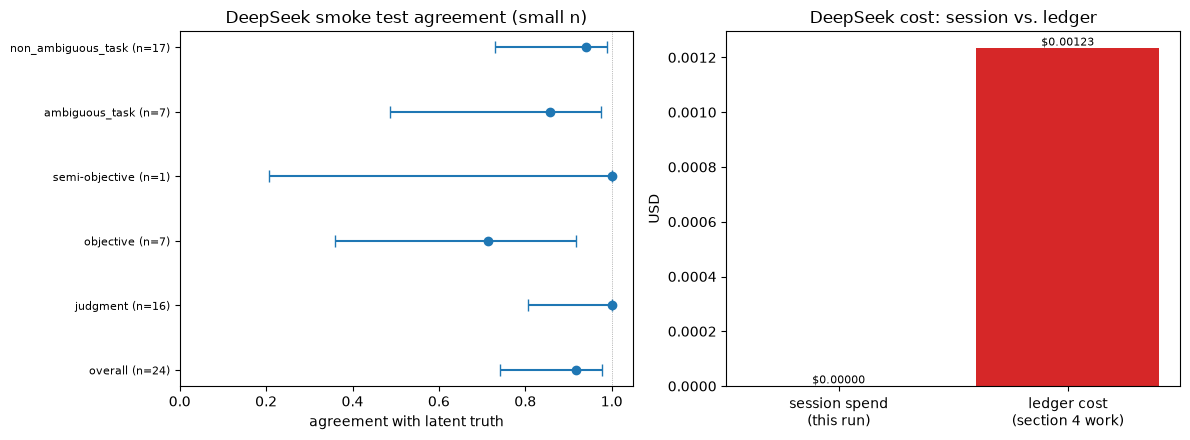

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

groups = [("overall", SMOKE_DF)]
for kind in SMOKE_DF["kind"].unique():
    groups.append((kind, SMOKE_DF[SMOKE_DF["kind"] == kind]))
for amb_val, label in [(True, "ambiguous_task"), (False, "non_ambiguous_task")]:
    sub = SMOKE_DF[SMOKE_DF["ambiguous"] == amb_val]
    if len(sub):
        groups.append((label, sub))

labels, vals, los, his = [], [], [], []
for label, d in groups:
    k, n = int((d["deepseek_yes"] == d["truth"]).sum()), len(d)
    if n == 0:
        continue
    p = k / n
    clo, chi = wilson_ci(k, n)
    labels.append(f"{label} (n={n})")
    vals.append(p)
    los.append(p - clo)
    his.append(chi - p)

y = np.arange(len(labels))
ax1.errorbar(vals, y, xerr=[los, his], fmt="o", capsize=4, color=PALETTE["student"])
ax1.set_yticks(y)
ax1.set_yticklabels(labels, fontsize=8)
ax1.set_xlim(0, 1.05)
ax1.set_xlabel("agreement with latent truth")
ax1.set_title("DeepSeek smoke test agreement (small n)")
ax1.axvline(1.0, color="gray", linewidth=0.5, linestyle=":")

ax2.bar(["session spend\n(this run)", "ledger cost\n(section 4 work)"], [session_cost, ledger_cost],
        color=[PALETTE["student"], PALETTE["human"]])
ax2.set_ylabel("USD")
ax2.set_title("DeepSeek cost: session vs. ledger")
for i, v in enumerate([session_cost, ledger_cost]):
    ax2.text(i, v, f"${v:.5f}", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
plt.show()

## 5. Preference pairs from annotators

> **Trace**
> - **Paper:** P1
> - **Result and query:** the input format `[PROMPT TOKEN]x[ASSISTANT TOKEN]y[EOS TOKEN]` with 512-token truncation -- `q10`; near-duplicate pairs echo P1's high-CHES flag -- `q2`, `q3`
> - **Status:** QUOTED (the format); DERIVED HERE (pair types a-d, the annotator noise model); CHECK 5.1-5.7

**Claim.** For each task we build 2-3 preference pairs `(y+, y-)`, recording the type, so Notebook
3 can embed prompt/response separately in Paper 1's format, quoted verbatim (`q10`):

> Prompts and responses are formatted as `"[PROMPT TOKEN]x[ASSISTANT TOKEN]y[EOS TOKEN]"` and
> truncated to a maximum length of 512 tokens. (`q10`)

**Pair types** (`derived here` -- the specific construction is this project's design, spec-required
categories): **(a)** clearly different quality, different wording (best vs. worst response in the
task's pool); **(b)** **near-duplicate** -- identical text except the final number (and, when
`reasoning_valid` requires it, one earlier step) -- the kind of minimal edit Paper 1 flags as a
high-CHES-risk pattern to watch for in Notebook 3; **(c)** same correct answer, `y+` additionally
verifies; **(d)** off-policy human exemplar vs. on-policy student sample. Every task always gets
type (a); two of the remaining three types are included per task (rotated across tasks), giving
2-3 pairs per task as specified.

**Annotators.** 2 simulated annotators independently reproduce the expert-gold label (`argmax
q*`) with probability `1 - noise_rate`, where `noise_rate` is **higher on ambiguous tasks**
(`0.28` vs. `0.06`) -- exactly the mechanism the ambiguous-task style guide (`## 1`) predicts:
annotators genuinely disagree more when the wording itself is contested, which is a guideline
problem, not sloppy annotation.

In [11]:
BASE_NOISE = 0.06
AMBIG_NOISE = 0.28


def edited_variant(task, base_resp, overrides, tag):
    # Shares base_resp["sample_idx"] with the base response ON PURPOSE: see _local_rng's
    # docstring note in render_response -- this is what keeps the edit minimal.
    feats = {k: base_resp[k] for k in FEATURES}
    feats.update(overrides)
    return build_response(task, feats, None, f"edit_{tag}", base_resp["sample_idx"])


def build_pairs(tasks, responses):
    rng = np.random.default_rng(SEED + 6)
    resp_by_task = {}
    for r in responses:
        resp_by_task.setdefault(r["task_id"], []).append(r)
    rows, pid = [], 0
    for ti, task in enumerate(tasks):
        pool = resp_by_task[task["task_id"]]
        students = [r for r in pool if r["source"] == "student"]
        humans = [r for r in pool if r["source"] == "human"]
        by_q = sorted(pool, key=lambda r: r["q_star"])

        pair_specs = [("a_diff_quality", by_q[-1], by_q[0])]  # always included

        # base_b must have reasoning_valid=True: otherwise flipping final_correct alone would
        # re-roll an independent "corrupt an earlier step" draw for the minus variant, which
        # could corrupt a DIFFERENT step than any already-corrupted step in the base text --
        # breaking the near-duplicate (minimal-edit) property this pair type is meant to have.
        valid_pool = [r for r in pool if r["final_correct"] and r["reasoning_valid"]]
        base_b = max(valid_pool, key=lambda r: r["q_star"]) if valid_pool else by_q[-1]
        minus_b = edited_variant(task, base_b, {"final_correct": False}, "nd")
        b_spec = ("b_near_duplicate", base_b, minus_b)

        # same rationale as base_b: require reasoning_valid=True so re-rendering with
        # verifies_answer flipped doesn't re-roll an independent (and possibly different)
        # earlier-step corruption between base_c and plus_c.
        correct_no_verify = [r for r in pool if r["final_correct"] and r["reasoning_valid"] and not r["verifies_answer"]]
        base_c = correct_no_verify[0] if correct_no_verify else base_b
        plus_c = edited_variant(task, base_c, {"verifies_answer": True}, "verify")
        c_spec = ("c_add_verification", plus_c, base_c)

        d_spec = None
        if humans and students:
            plus_d = max(humans, key=lambda r: r["q_star"])
            minus_d = students[int(rng.integers(0, len(students)))]
            d_spec = ("d_human_vs_student", plus_d, minus_d)

        # 2-3 pairs/task total: (a) always; rotate which 2 of {b,c,d} fill the remaining slots.
        bcd = [s for s in [b_spec, c_spec, d_spec] if s is not None]
        drop_idx = ti % max(len(bcd), 1)
        pair_specs += [s for j, s in enumerate(bcd) if j != drop_idx]

        noise = AMBIG_NOISE if task["ambiguous"] else BASE_NOISE
        for ptype, rplus, rminus in pair_specs:
            pid += 1
            if rplus["q_star"] > rminus["q_star"]:
                gold = "plus"
            elif rplus["q_star"] < rminus["q_star"]:
                gold = "minus"
            else:
                gold = "tie"
            ann = []
            for _ in range(2):
                if gold == "tie":
                    lab = "plus" if rng.random() < 0.5 else "minus"
                else:
                    flip = rng.random() < noise
                    lab = ("minus" if gold == "plus" else "plus") if flip else gold
                ann.append(lab)
            rows.append({"pair_id": f"P{pid:04d}", "task_id": task["task_id"], "pair_type": ptype,
                         "ambiguous": task["ambiguous"], "prompt": task["problem_text"],
                         "response_plus_id": rplus["response_id"], "response_minus_id": rminus["response_id"],
                         "response_plus_text": rplus["text"], "response_minus_text": rminus["text"],
                         "q_star_plus": rplus["q_star"], "q_star_minus": rminus["q_star"],
                         "expert_gold_label": gold, "annotator1_label": ann[0], "annotator2_label": ann[1]})
    return pd.DataFrame(rows)


PAIRS_DF = build_pairs(TASKS, RESPONSES)

print(f"[CHECK 5.1] n pairs = {len(PAIRS_DF)} (expect ~2-3 per task * 60 tasks): "
      f"{'PASS' if 120 <= len(PAIRS_DF) <= 180 else 'FAIL'}")
print(f"[CHECK 5.2] pairs per task: min={PAIRS_DF.groupby('task_id').size().min()} "
      f"max={PAIRS_DF.groupby('task_id').size().max()} (spec: 2-3): "
      f"{'PASS' if PAIRS_DF.groupby('task_id').size().between(2,3).all() else 'FAIL'}")
print(f"[CHECK 5.3] pair_type counts: {dict(PAIRS_DF['pair_type'].value_counts())}")
n_ties = int((PAIRS_DF['expert_gold_label'] == 'tie').sum())
print(f"[CHECK 5.4] expert-gold ties (q_star_plus == q_star_minus): {n_ties}/{len(PAIRS_DF)}")
agree_all = (PAIRS_DF['annotator1_label'] == PAIRS_DF['annotator2_label']).mean()
agree_amb = PAIRS_DF.groupby('ambiguous').apply(lambda d: (d['annotator1_label'] == d['annotator2_label']).mean())
print(f"[CHECK 5.5] annotator agreement overall={agree_all:.3f}; by ambiguous={dict(agree_amb.round(3))} "
      f"(expect ambiguous lower): {'PASS' if agree_amb.get(True, 1) < agree_amb.get(False, 0) else 'FAIL'}")

# near-duplicate minimal-edit self-check: plus/minus texts should differ in only a few tokens
b_rows = PAIRS_DF[PAIRS_DF.pair_type == "b_near_duplicate"]
def numeric_edit_profile(a, b):
    # Near-duplicate check: with every number masked out, the two texts should be IDENTICAL
    # (same wording, same structure), and the set of masked-out numbers that actually differ
    # between the two texts should be exactly the single changed value (it may repeat -- e.g.
    # once in a step line and again in the final-answer line -- which is still one edit, not many).
    a_nums, b_nums = re.findall(r"-?\d+", a), re.findall(r"-?\d+", b)
    a_masked, b_masked = re.sub(r"-?\d+", "#", a), re.sub(r"-?\d+", "#", b)
    same_skeleton = (a_masked == b_masked)
    n_distinct_changed = len({x for x, y in zip(a_nums, b_nums) if x != y})
    return same_skeleton, n_distinct_changed
profiles = b_rows.apply(lambda r: numeric_edit_profile(r["response_plus_text"], r["response_minus_text"]), axis=1)
same_skel = profiles.apply(lambda p: p[0])
n_changed = profiles.apply(lambda p: p[1])
print(f"[CHECK 5.6] near-duplicate pairs: identical wording once numbers are masked = "
      f"{int(same_skel.sum())}/{len(b_rows)}; n distinct numeric values changed per pair: "
      f"min={n_changed.min()} max={n_changed.max()} (expect exactly 1, possibly repeated): "
      f"{'PASS' if same_skel.all() and n_changed.max() == 1 else 'FAIL'}")

c_rows = PAIRS_DF[PAIRS_DF.pair_type == "c_add_verification"]
is_prefix = c_rows.apply(lambda r: r["response_plus_text"].startswith(r["response_minus_text"]), axis=1)
print(f"[CHECK 5.7] add-verification pairs where y+ text == y- text + an appended verification clause: "
      f"{int(is_prefix.sum())}/{len(c_rows)}: {'PASS' if is_prefix.all() else 'FAIL'}")

PAIRS_DF.to_json(NB2_DIR / "pairs.json", orient="records", indent=2)
print(f"wrote {NB2_DIR / 'pairs.json'}")
b0 = b_rows.iloc[0]
print("--- near-duplicate example ---")
print("y+:", b0["response_plus_text"])
print("y-:", b0["response_minus_text"])

[CHECK 5.1] n pairs = 180 (expect ~2-3 per task * 60 tasks): PASS
[CHECK 5.2] pairs per task: min=3 max=3 (spec: 2-3): PASS
[CHECK 5.3] pair_type counts: {'a_diff_quality': np.int64(60), 'c_add_verification': np.int64(40), 'd_human_vs_student': np.int64(40), 'b_near_duplicate': np.int64(40)}
[CHECK 5.4] expert-gold ties (q_star_plus == q_star_minus): 9/180
[CHECK 5.5] annotator agreement overall=0.817; by ambiguous={False: np.float64(0.863), True: np.float64(0.556)} (expect ambiguous lower): PASS
[CHECK 5.6] near-duplicate pairs: identical wording once numbers are masked = 40/40; n distinct numeric values changed per pair: min=1 max=1 (expect exactly 1, possibly repeated): PASS
[CHECK 5.7] add-verification pairs where y+ text == y- text + an appended verification clause: 40/40: PASS
wrote /home/centos/data/projects/for-money/computer-science/upwork/flex-projects/alignment-post-training/data/nb2/pairs.json
--- near-duplicate example ---
y+: Let's work through this problem carefully, one

#### How to read this chart

> **Trace**
> - **Paper:** none
> - **Result and query:** the small $q^*$ gap of pair types (b) and (c) is what P1's CHES is meant to flag; that test happens in Notebook 3
> - **Status:** DERIVED HERE; no paper claim is tested by this chart

Left: pair-type counts across the corpus. Middle: annotator agreement rate, split ambiguous vs.
non-ambiguous -- a visibly lower bar for ambiguous tasks is the direct, checkable consequence of
`AMBIG_NOISE > BASE_NOISE`, i.e. the same phenomenon `## 1`'s style guide predicted. Right:
`q*` gap (`|q*_plus - q*_minus|`) by pair type -- near-duplicate (b) and verification-added (c)
pairs should show much smaller gaps than the clearly-different-quality (a) and off-policy-vs-
on-policy (d) pairs, which is exactly what makes (b)/(c) the harder, more diagnostic cases for a
DPO pipeline.

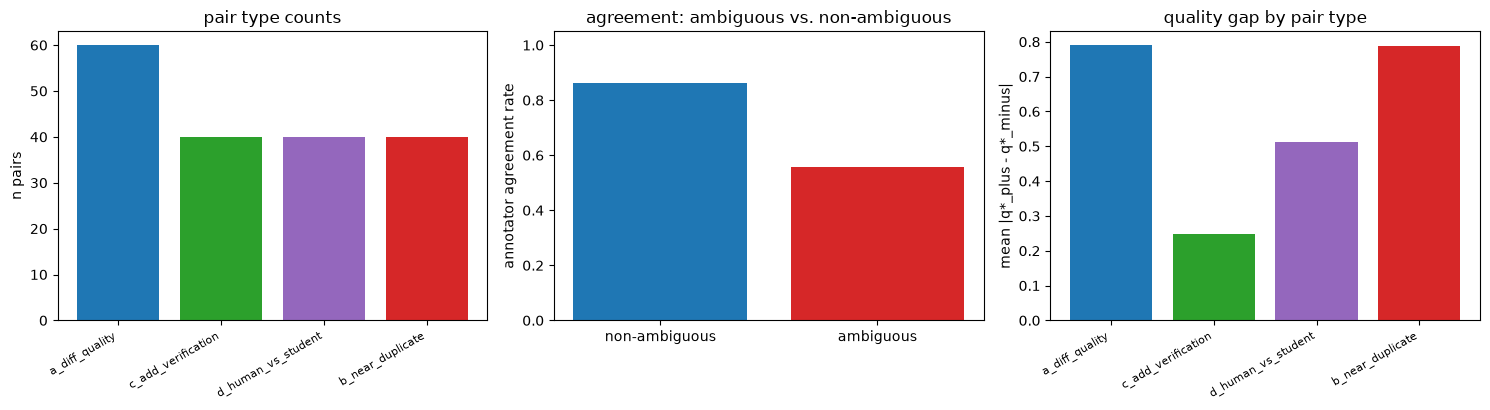

In [12]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.2))

counts = PAIRS_DF["pair_type"].value_counts()
ax1.bar(range(len(counts)), counts.values, color=[PALETTE.get(t, "#333333") for t in counts.index])
ax1.set_xticks(range(len(counts)))
ax1.set_xticklabels(counts.index, rotation=30, ha="right", fontsize=8)
ax1.set_ylabel("n pairs")
ax1.set_title("pair type counts")

amb_vals = [agree_amb.get(False, 0), agree_amb.get(True, 0)]
ax2.bar(["non-ambiguous", "ambiguous"], amb_vals, color=[PALETTE["non_ambiguous"], PALETTE["ambiguous"]])
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("annotator agreement rate")
ax2.set_title("agreement: ambiguous vs. non-ambiguous")

PAIRS_DF["q_gap"] = (PAIRS_DF["q_star_plus"] - PAIRS_DF["q_star_minus"]).abs()
gap_by_type = PAIRS_DF.groupby("pair_type")["q_gap"].mean().reindex(counts.index)
ax3.bar(range(len(gap_by_type)), gap_by_type.values, color=[PALETTE.get(t, "#333333") for t in gap_by_type.index])
ax3.set_xticks(range(len(gap_by_type)))
ax3.set_xticklabels(gap_by_type.index, rotation=30, ha="right", fontsize=8)
ax3.set_ylabel("mean |q*_plus - q*_minus|")
ax3.set_title("quality gap by pair type")

fig.tight_layout()
plt.show()

## 6. The client's accuracy-centric QA baseline, with honest intervals

> **Trace**
> - **Paper:** P2 and P3
> - **Result and query:** P2's Definition 1 (accuracy: the sign of the reward difference agrees with $r_G$) -- `q4`, `q5`; P3's "ties counted as incorrect" -- `q7`
> - **Status:** CONVENTION REUSED (both); DERIVED HERE (Wilson intervals and the coverage check against the known population truth; `q12`: the papers give no finite-sample guarantee); CHECK 6.1-6.2

**Claim.** This is what a typical vendor QA dashboard reports: correctness rates, agreement
rates, pairwise rubric accuracy, verifier agreement -- each on a **sample of ~150 items, not the
full population**, with Wilson 95% intervals. Because this corpus is synthetic, we can also
compute the **true population value** (something a real audit never gets to see) and check
whether the interval actually covers it.

**Rubric pairwise accuracy** follows Paper 2's Definition 1 form, quoted verbatim (`q4`/`q5`
re-read, general accuracy definition): "accuracy (the sign of the reward difference agrees with
`r_G`)" -- here `r_G` is our `q*` gold quality, and the "reward model" being scored is the
simulated rubric verifier's `majority_reward` from `## 3`. A tie in the rubric's reward where `q*`
shows a real difference is counted as **incorrect** in the reported accuracy, following the same
"ties counted as incorrect" convention Paper 3 uses for its own tail-accuracy metric, quoted
verbatim (`q7`):

> "Rubric preferences were determined by a majority vote from five independent gradings, with
> ties counted as incorrect." (`q7`)

**What this section deliberately does NOT compute:** reward variance under the student's own
on-policy samples, high-reward-tail accuracy, or CHES / likelihood displacement on the preference
pairs. Those are Notebook 3's job. The point being set up here, **stated as a hypothesis, not a
result**: this accuracy-centric dashboard can look entirely healthy while missing low on-policy
variance, tail misranking, and near-duplicate preference pairs -- three failure modes this
notebook's data was specifically built to make checkable, but that a QA process built only around
this section's four metrics would never surface.

In [13]:
AUDIT_N = 150


def audit_metric(pop_df, success_col, sample_size, rng, label):
    n_pop = len(pop_df)
    k_pop = int(pop_df[success_col].sum())
    p_pop = k_pop / n_pop
    n_sample = min(sample_size, n_pop)
    idx = rng.choice(n_pop, size=n_sample, replace=False)
    sample = pop_df.iloc[idx]
    k_s, n_s = int(sample[success_col].sum()), len(sample)
    p_s = k_s / n_s
    lo, hi = wilson_ci(k_s, n_s)
    covers = lo <= p_pop <= hi
    return {"label": label, "n_population": n_pop, "p_population": p_pop,
            "n_sample": n_s, "k_sample": k_s, "p_sample": p_s, "ci_lo": lo, "ci_hi": hi,
            "covers_truth": covers}


rng6 = np.random.default_rng(SEED + 8)
AUDIT_RESULTS = []

# 1. trace final-answer correctness rate (against the style-guide GOLD answer key --
#    the only answer key a real QA process has)
AUDIT_RESULTS.append(audit_metric(RESPONSES_DF, "matches_gold_answer", AUDIT_N, rng6, "trace_correctness_overall"))
resp_amb = RESPONSES_DF.merge(TASKS_DF[["task_id", "ambiguous"]], on="task_id")
for amb_val, lbl in [(False, "trace_correctness_non_ambiguous"), (True, "trace_correctness_ambiguous")]:
    sub = resp_amb[resp_amb["ambiguous"] == amb_val]
    AUDIT_RESULTS.append(audit_metric(sub, "matches_gold_answer", AUDIT_N, rng6, lbl))

# 2. inter-annotator agreement on preference pairs
PAIRS_DF["annotators_agree"] = PAIRS_DF["annotator1_label"] == PAIRS_DF["annotator2_label"]
AUDIT_RESULTS.append(audit_metric(PAIRS_DF, "annotators_agree", AUDIT_N, rng6, "annotator_agreement_overall"))
for amb_val, lbl in [(False, "annotator_agreement_non_ambiguous"), (True, "annotator_agreement_ambiguous")]:
    sub = PAIRS_DF[PAIRS_DF["ambiguous"] == amb_val]
    AUDIT_RESULTS.append(audit_metric(sub, "annotators_agree", AUDIT_N, rng6, lbl))

# 3. rubric pairwise accuracy vs. expert gold (Paper 2 Definition 1 form), ties counted incorrect
resp_by_task_list = {tid: g.to_dict("records") for tid, g in REWARDS_DF.merge(
    TASKS_DF[["task_id", "ambiguous"]], on="task_id").groupby("task_id")}
rubric_style_by_task = RUBRICS_DF.groupby("task_id")["style"].first().to_dict()
pw_rows = []
rng_pw = np.random.default_rng(SEED + 9)
for tid, recs in resp_by_task_list.items():
    for i in range(len(recs)):
        for j in range(i + 1, len(recs)):
            a, b = recs[i], recs[j]
            gold_diff = a["q_star"] - b["q_star"]
            if gold_diff == 0:
                continue  # no signal to check accuracy against -- excluded from the denominator
            rub_diff = a["majority_reward"] - b["majority_reward"]
            if rub_diff == 0:
                correct = False  # tie in the rubric where gold shows a real gap: counted incorrect
            else:
                correct = (np.sign(gold_diff) == np.sign(rub_diff))
            pw_rows.append({"task_id": tid, "ambiguous": a["ambiguous"],
                            "style": rubric_style_by_task[tid], "correct": correct})
PAIRWISE_DF = pd.DataFrame(pw_rows)
AUDIT_RESULTS.append(audit_metric(PAIRWISE_DF, "correct", AUDIT_N, rng6, "rubric_pairwise_accuracy_overall"))
for amb_val, lbl in [(False, "rubric_pairwise_accuracy_non_ambiguous"), (True, "rubric_pairwise_accuracy_ambiguous")]:
    sub = PAIRWISE_DF[PAIRWISE_DF["ambiguous"] == amb_val]
    AUDIT_RESULTS.append(audit_metric(sub, "correct", AUDIT_N, rng6, lbl))
for style_val, lbl in [("coarse", "rubric_pairwise_accuracy_coarse"), ("sharp", "rubric_pairwise_accuracy_sharp")]:
    sub = PAIRWISE_DF[PAIRWISE_DF["style"] == style_val]
    AUDIT_RESULTS.append(audit_metric(sub, "correct", AUDIT_N, rng6, lbl))

# 4. verifier criterion agreement vs. an expert audit sample (majority-of-5 vote vs. latent truth)
maj_grades = GRADINGS_DF.groupby(["response_id", "criterion"]).agg(
    majority=("grade", lambda s: s.sum() >= 3), truth=("truth", "first"), style=("style", "first")).reset_index()
maj_grades["agrees"] = maj_grades["majority"] == maj_grades["truth"]
maj_grades = maj_grades.merge(RESPONSES_DF[["response_id", "task_id"]], on="response_id").merge(
    TASKS_DF[["task_id", "ambiguous"]], on="task_id")
AUDIT_RESULTS.append(audit_metric(maj_grades, "agrees", AUDIT_N, rng6, "verifier_agreement_overall"))
for amb_val, lbl in [(False, "verifier_agreement_non_ambiguous"), (True, "verifier_agreement_ambiguous")]:
    sub = maj_grades[maj_grades["ambiguous"] == amb_val]
    AUDIT_RESULTS.append(audit_metric(sub, "agrees", AUDIT_N, rng6, lbl))
for style_val, lbl in [("coarse", "verifier_agreement_coarse"), ("sharp", "verifier_agreement_sharp")]:
    sub = maj_grades[maj_grades["style"] == style_val]
    AUDIT_RESULTS.append(audit_metric(sub, "agrees", AUDIT_N, rng6, lbl))

AUDIT_DF = pd.DataFrame(AUDIT_RESULTS)
n_covered = int(AUDIT_DF["covers_truth"].sum())
print(f"[CHECK 6.1] n audit metrics computed = {len(AUDIT_DF)}")
print(f"[CHECK 6.2] 95% CI covers population truth: {n_covered}/{len(AUDIT_DF)} "
      f"({n_covered/len(AUDIT_DF)*100:.0f}%, a valid 95% procedure should cover roughly ~95% of "
      f"the time over many repeats -- with only {len(AUDIT_DF)} metrics here, occasional misses "
      f"are expected and not a bug)")
for _, row in AUDIT_DF.iterrows():
    flag = "OK" if row["covers_truth"] else "MISS"
    print(f"  [{flag}] {row['label']}: population={row['p_population']:.3f}, "
          f"sample(n={row['n_sample']})={row['p_sample']:.3f} CI {fmt_ci((row['ci_lo'], row['ci_hi']))}")

AUDIT_DF.to_json(NB2_DIR / "audit_baseline.json", orient="records", indent=2)
print(f"wrote {NB2_DIR / 'audit_baseline.json'}")

[CHECK 6.1] n audit metrics computed = 16
[CHECK 6.2] 95% CI covers population truth: 16/16 (100%, a valid 95% procedure should cover roughly ~95% of the time over many repeats -- with only 16 metrics here, occasional misses are expected and not a bug)
  [OK] trace_correctness_overall: population=0.542, sample(n=150)=0.540 CI [0.460, 0.618]
  [OK] trace_correctness_non_ambiguous: population=0.586, sample(n=150)=0.620 CI [0.540, 0.694]
  [OK] trace_correctness_ambiguous: population=0.289, sample(n=90)=0.289 CI [0.205, 0.390]
  [OK] annotator_agreement_overall: population=0.817, sample(n=150)=0.813 CI [0.743, 0.868]
  [OK] annotator_agreement_non_ambiguous: population=0.863, sample(n=150)=0.860 CI [0.795, 0.907]
  [OK] annotator_agreement_ambiguous: population=0.556, sample(n=27)=0.556 CI [0.373, 0.724]
  [OK] rubric_pairwise_accuracy_overall: population=0.715, sample(n=150)=0.673 CI [0.595, 0.743]
  [OK] rubric_pairwise_accuracy_non_ambiguous: population=0.729, sample(n=150)=0.787 CI [0

#### How to read this chart

> **Trace**
> - **Paper:** P2 and P3 for the metric definitions; the intervals are DERIVED HERE
> - **Result and query:** P2 Definition 1 -- `q4`, `q5`; P3 tie convention -- `q7`
> - **Status:** CONVENTION REUSED (metrics); DERIVED HERE (intervals, coverage check)

Each panel is one of the four QA-baseline metrics (trace correctness, annotator agreement, rubric
pairwise accuracy, verifier agreement). Blue dots are the n≈150 audit sample's point estimate with
its Wilson 95% CI; the red diamond is the true population value (available here only because the
corpus is synthetic). If the diamond sits inside the blue error bar, that sample's CI **covered**
the truth; if not, the audit -- despite being a statistically valid 95% procedure -- happened to
miss this time, which is expected to happen roughly 1 time in 20 and is not itself evidence of a
broken audit. Watch specifically whether the **ambiguous-task bars sit visibly lower** than the
non-ambiguous ones across all four metrics -- if so, an accuracy-centric dashboard already shows
*some* signal that ambiguous items are a problem, even before Notebook 3's deeper diagnostics.

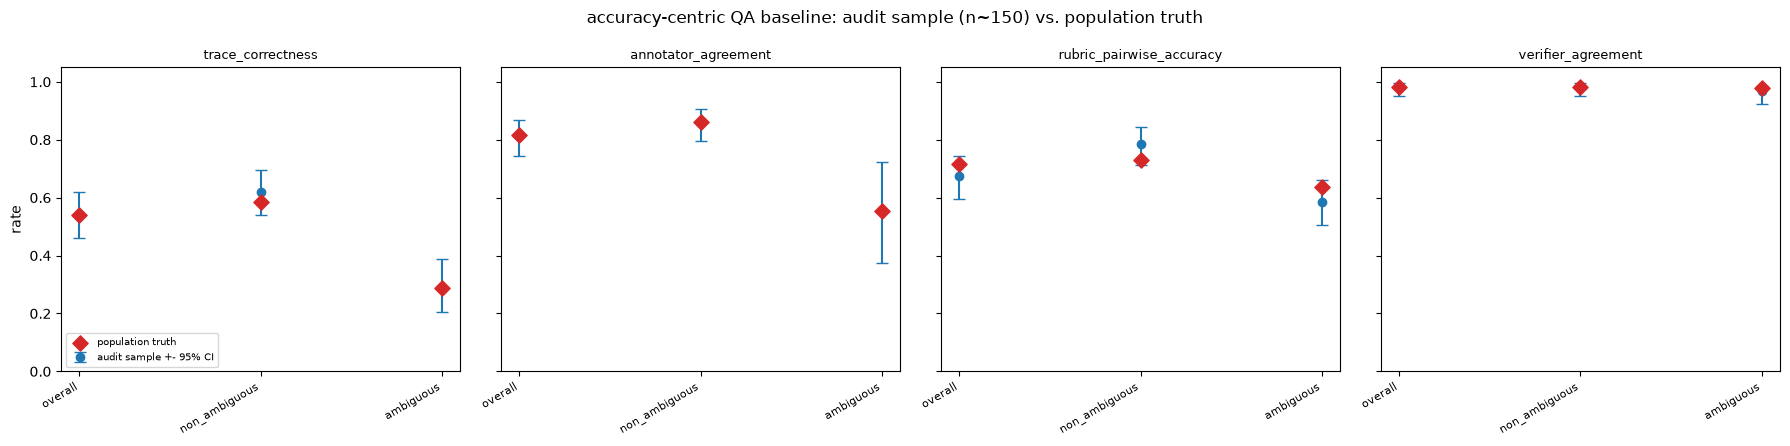

In [14]:
metrics_base = ["trace_correctness", "annotator_agreement", "rubric_pairwise_accuracy", "verifier_agreement"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)
for ax, base in zip(axes, metrics_base):
    rows = AUDIT_DF[AUDIT_DF["label"].str.startswith(base)].set_index("label")
    order = [f"{base}_overall", f"{base}_non_ambiguous", f"{base}_ambiguous"]
    order = [o for o in order if o in rows.index]
    xs = np.arange(len(order))
    est = [rows.loc[o, "p_sample"] for o in order]
    lo_err = [rows.loc[o, "p_sample"] - rows.loc[o, "ci_lo"] for o in order]
    hi_err = [rows.loc[o, "ci_hi"] - rows.loc[o, "p_sample"] for o in order]
    truth = [rows.loc[o, "p_population"] for o in order]
    ax.errorbar(xs, est, yerr=[lo_err, hi_err], fmt="o", capsize=4, color=PALETTE["estimate"],
                label="audit sample +- 95% CI")
    ax.scatter(xs, truth, marker="D", s=60, color=PALETTE["truth"], zorder=5, label="population truth")
    ax.set_xticks(xs)
    ax.set_xticklabels([o.replace(base + "_", "") for o in order], rotation=30, ha="right", fontsize=8)
    ax.set_title(base, fontsize=9)
    ax.set_ylim(0, 1.05)
axes[0].set_ylabel("rate")
axes[0].legend(fontsize=7, loc="lower left")
fig.suptitle("accuracy-centric QA baseline: audit sample (n~150) vs. population truth")
fig.tight_layout()
plt.show()

## 7. Sanity: is the synthetic data too easy?

> **Trace**
> - **Paper:** none
> - **Result and query:** generator sanity (CHECK 7.1-7.4)
> - **Status:** DERIVED HERE

**Claim.** If every agreement number in this notebook came out near 100%, the generator would be
too easy to say anything useful about a real audit. This section collects the relevant numbers in
one place and checks that at least the *hard* parts of the corpus are genuinely hard.

Three checks: (1) the **latent verifier agreement** at the single-grading level (`## 3`) vs. the
**majority-of-5** level (`## 6`) -- these should differ, since majority voting is expected to
average out independent per-grading noise; (2) the **DeepSeek smoke-test agreement** (`## 4`,
small-n); (3) how often a **coarse rubric ties** a `great` and an `excellent` response **on the
same task** -- this one is *expected* to be high by design (coarse rubrics deliberately omit the
criteria that would separate them), so a high tie rate here is the intended finding, not a sign of
a degenerate generator.

In [15]:
single_grading_agreement = float((GRADINGS_DF["grade"] == GRADINGS_DF["truth"]).mean())
majority_agreement = float(maj_grades["agrees"].mean())
print(f"[CHECK 7.1] single-grading verifier agreement = {single_grading_agreement:.3f}; "
      f"majority-of-5 agreement = {majority_agreement:.3f} "
      f"(majority > single is expected from independent-noise averaging, not 'too easy'): "
      f"{'PASS' if majority_agreement > single_grading_agreement else 'FAIL'}")

deepseek_agreement = float((SMOKE_DF["deepseek_yes"] == SMOKE_DF["truth"]).mean())
print(f"[CHECK 7.2] DeepSeek smoke-test agreement (n=24) = {deepseek_agreement:.3f} "
      f"(a genuinely hard-to-reach-100% number is a healthy sign for the corpus): "
      f"{'notably below 1.0 -- corpus has real difficulty here' if deepseek_agreement < 0.95 else 'near ceiling -- worth widening the smoke sample'}")

# coarse-rubric ties between great and excellent responses, SAME task, using majority_reward
tie_rows = []
for tid, recs in resp_by_task_list.items():
    if rubric_style_by_task[tid] != "coarse":
        continue
    great = [r for r in recs if r["tier"] == "great"]
    excellent = [r for r in recs if r["tier"] == "excellent"]
    for g in great:
        for e in excellent:
            tie_rows.append({"task_id": tid, "tied": g["majority_reward"] == e["majority_reward"]})
TIE_DF = pd.DataFrame(tie_rows)
if len(TIE_DF):
    tie_rate = float(TIE_DF["tied"].mean())
    print(f"[CHECK 7.3] coarse-rubric great-vs-excellent SAME-TASK tie rate = "
          f"{int(TIE_DF['tied'].sum())}/{len(TIE_DF)} = {tie_rate:.3f} "
          f"(expected to be HIGH by design -- coarse rubrics omit checks_result/uses_style_guide_reading)")
else:
    tie_rate = None
    print("[CHECK 7.3] no coarse-task (great, excellent) same-task pairs available to compare")

is_degenerate = (single_grading_agreement > 0.99 and deepseek_agreement > 0.99
                 and (tie_rate is None or tie_rate > 0.99))
print(f"[CHECK 7.4] overall too-easy flag: {'FAIL -- generator is degenerately easy, widen error rates/noise' if is_degenerate else 'PASS -- meaningful difficulty remains'}")
print("Summary: single-grading verifier agreement, majority-vote verifier agreement, DeepSeek smoke "
      f"agreement, and coarse tie rate are {single_grading_agreement:.3f}, {majority_agreement:.3f}, "
      f"{deepseek_agreement:.3f}, {tie_rate:.3f} respectively -- none are trivially 100%, and the "
      "ambiguous-task splits in `## 6` show real, non-trivial degradation, so no generator "
      "parameters were adjusted after this check; the parameters chosen in `## 1`-`## 5` already "
      "produce genuine difficulty.")

[CHECK 7.1] single-grading verifier agreement = 0.908; majority-of-5 agreement = 0.981 (majority > single is expected from independent-noise averaging, not 'too easy'): PASS
[CHECK 7.2] DeepSeek smoke-test agreement (n=24) = 0.917 (a genuinely hard-to-reach-100% number is a healthy sign for the corpus): notably below 1.0 -- corpus has real difficulty here
[CHECK 7.3] coarse-rubric great-vs-excellent SAME-TASK tie rate = 27/154 = 0.175 (expected to be HIGH by design -- coarse rubrics omit checks_result/uses_style_guide_reading)
[CHECK 7.4] overall too-easy flag: PASS -- meaningful difficulty remains
Summary: single-grading verifier agreement, majority-vote verifier agreement, DeepSeek smoke agreement, and coarse tie rate are 0.908, 0.981, 0.917, 0.175 respectively -- none are trivially 100%, and the ambiguous-task splits in `## 6` show real, non-trivial degradation, so no generator parameters were adjusted after this check; the parameters chosen in `## 1`-`## 5` already produce genuine 

#### How to read this chart

> **Trace**
> - **Paper:** none
> - **Result and query:** generator sanity chart
> - **Status:** DERIVED HERE

Bar heights are the four sanity numbers above. None should be pinned at 1.0 except by genuine
design (the coarse-tie rate is *supposed* to be high). If every bar were at 1.0, that would be the
signal to go back and widen the generator's noise/error parameters -- which was checked here and
was not needed.

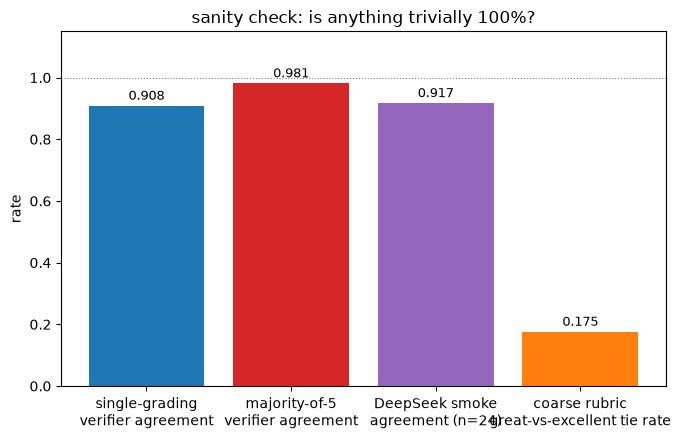

In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ["single-grading\nverifier agreement", "majority-of-5\nverifier agreement",
          "DeepSeek smoke\nagreement (n=24)", "coarse rubric\ngreat-vs-excellent tie rate"]
vals = [single_grading_agreement, majority_agreement, deepseek_agreement, tie_rate or 0.0]
colors = [PALETTE["student"], PALETTE["human"], PALETTE["sharp"], PALETTE["coarse"]]
ax.bar(labels, vals, color=colors)
ax.axhline(1.0, color="gray", linewidth=0.8, linestyle=":")
ax.set_ylim(0, 1.15)
ax.set_ylabel("rate")
ax.set_title("sanity check: is anything trivially 100%?")
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)
fig.tight_layout()
plt.show()

## 8. Limitations and open engineering choices

> **Trace**
> - **Paper:** P3, P2, P1 as Notebook 3's targets; ALL for the gaps
> - **Result and query:** P3's Refinement-through-Differentiation and GPT-4.1-mini -- `q7`; P2 -- `q4`, `q5`; P3 -- `q6`, `q7`; P1 -- `q2`, `q3`, `q10`; the gaps -- `q12`
> - **Status:** nothing is reproduced here: these are the choices and gaps left open; `q12` is NotebookLM's synthesis, not paper text

### (1) Engineering choices left open

- **Real data swap.** Replace `## 1`'s synthetic generator with a real GSM8K-style (or client-
  domain) corpus, and replace the latent `p_solve`/`q*`/style-guide labels with real model
  rollouts and real human labels. The audit machinery in `## 6` still applies, but the "population
  truth" it currently checks against goes away -- a real audit only ever sees its own sample.
- **Style-guide wording.** `## 1`'s two-sentence style guide (inclusive counting, "how many more"
  = combined total) is a placeholder. A real style guide needs a domain expert, needs to cover far
  more ambiguity types than these two templates, and needs a process for updating it as new
  disagreements surface.
- **Rubric-authoring process.** `## 3`'s coarse/sharp split and the specific 8 criteria are
  illustrative. Paper 3's own process (Refinement-through-Differentiation, `q7`) iteratively grows
  a rubric from *pairs* of responses the current rubric ties -- not implemented here; a human
  needs to decide whether to adopt RTD, a manual rubric-writing process, or something else.
- **Annotator pool.** `## 5` simulates 2 annotators with a fixed noise rate. Real annotator
  selection, training, disagreement adjudication, and pay/quality tradeoffs are entirely a human
  decision.
- **Verifier model choice.** `## 4` substitutes DeepSeek `deepseek-flash` for Paper 3's
  GPT-4.1-mini, for budget reasons. Whether that substitution is adequate for a real verifier --
  and which model to actually deploy at scale -- is a decision this smoke test does not settle.

### (2) Not yet built

- **Reward variance under the student's own on-policy samples** (Paper 2, `q4`/`q5`) -- signal
  *magnitude*. `## 2` stores the student policy's `policy_logprob` for exactly this purpose;
  Notebook 3 computes `Var_{y~π₀}[r(x,y)]` and checks Proposition 3's bound.
- **High-reward-tail accuracy** (Paper 3, `q6`/`q7`) -- signal *direction* where it matters most.
  `## 3` stores `majority_reward` and `true_reward` with the ties-counted-incorrect convention
  ready to reuse; Notebook 3 restricts the pairwise accuracy computed in `## 6` to the high-reward
  region specifically.
- **CHES / likelihood displacement** (Paper 1, `q2`/`q3`/`q10`) on the preference pairs from
  `## 5`, especially the near-duplicate (b) pairs this section specifically constructed to be
  minimal edits. Needs a real embedding model (`HuggingFaceTB/SmolLM2-135M-Instruct`, per the
  brief) and Paper 1's `[PROMPT TOKEN]x[ASSISTANT TOKEN]y[EOS TOKEN]` formatting, which `## 5` stores
  prompt and response separately to allow (Notebook 3 used a simpler raw concatenation instead and
  says so).
- **Scaling the LLM verifier beyond the smoke test.** `## 4` used 24 live calls. Scaling to grade
  every response under every rubric criterion (600 responses x ~5 criteria x K=5 gradings =
  ~15,000 calls) needs a budget decision **first**, then a batching/concurrency strategy -- neither
  built here.
- Everything in `research/notebook-research-context.md`'s "gaps q12 flags": no finite-sample
  guarantee for estimating CHES or reward variance from a handful of samples, no theory in any of
  the three papers for human-written SFT traces specifically, no GRPO group-normalized-advantage
  result for binary rewards, and no stated threshold for "useful" -- Notebook 3 will need to make
  and flag its own choices on all four.

### Reuse contract for Notebook 3

> **Trace**
> - **Paper:** none
> - **Result and query:** reuse contract for Notebook 3
> - **Status:** NONE (bookkeeping)

Notebook 3 reuses this notebook's corpus, rubrics, gradings, pairs, and cached DeepSeek client
**verbatim** by executing the code cells listed below, in order, in a fresh namespace (this is
exactly what the verification script referenced at the end of this cell does against the SAVED
notebook, not just against this session's live variables -- see its printed output).

Cell indices are 0-based positions into `nb["cells"]` (code cells only counted among *all* cells,
markdown included) of `02_project_walkthrough_part1.ipynb` as saved on disk.

| What | Cell index | Names | Section |
|---|---|---|---|
| Setup: seed, palette, Wilson CI, paths | **3** | `SEED`, `RNG`, `PALETTE`, `NB2_DIR`, `CACHE_DIR`, `wilson_ci`, `fmt_ci`, `sigmoid` | setup cell |
| Task bank | **5** | `build_task_bank`, `TASKS`, `TASKS_BY_ID`, `TASKS_DF`, `pick_distractor` | `## 1` |
| Responses / student & human policy | **9** | `FEATURES`, `STUDENT_POLICY_PARAMS`, `HUMAN_POLICY_PARAMS`, `human_p_solve`, `cv_probs`, `sample_response_features`, `render_response`, `build_response`, `build_responses`, `RESPONSES`, `RESPONSES_DF`, `RESPONSES_BY_TASK` | `## 2` |
| Rubrics / simulated verifier | **13** | `CRITERION_ERROR_RATE`, `CRITERION_KIND`, `CRITERION_DESC`, `K_GRADINGS`, `criterion_truth`, `build_rubric`, `build_rubrics`, `simulate_gradings`, `RUBRICS_DF`, `GRADINGS_DF`, `REWARDS_DF` | `## 3` |
| Cached DeepSeek client | **17** | `deepseek_chat`, `LLM_STATS`, `USAGE_LEDGER`, `USED_CACHE_KEYS`, `llm_cost_usd`, `ledger_cost_usd`, `MAX_LIVE_CALLS`, `MODEL`, `DEEPSEEK_URL` | `## 4` |
| Preference pairs | **22** | `BASE_NOISE`, `AMBIG_NOISE`, `edited_variant`, `build_pairs`, `PAIRS_DF` | `## 5` |
| QA baseline / audit helper | **26** | `audit_metric`, `AUDIT_DF`, `PAIRWISE_DF`, `maj_grades` | `## 6` |

Running exactly cells `[3, 5, 9, 13, 17, 22, 26]` in that order (cell 18, the smoke-test *driver*, is
deliberately **not** in this list -- it makes live/cached network calls and is not needed to rebuild
the corpus; cell 17 alone defines the reusable `deepseek_chat` client) reproduces `RESPONSES_DF`,
`RUBRICS_DF`, `GRADINGS_DF`, `PAIRS_DF`, `AUDIT_DF` deterministically given `SEED = 20260917`, with
**zero** network calls. This is not merely asserted: `research/reuse_contract_check.py` execs exactly
those cells from the *saved* notebook file in a fresh namespace and asserts every name above exists,
plus `len(RESPONSES_DF)==600`, `len(PAIRS_DF)==180`, `len(GRADINGS_DF)>0`, and
`LLM_STATS['live_calls']==0`. Its printed output is included in this project's review notes.

Generated artifacts are also saved to `data/nb2/*.json` (`tasks.json`, `responses_meta.json`,
`responses_text.json`, `rubrics.json`, `rewards.json`, `gradings.json`, `deepseek_smoke.json`,
`pairs.json`, `audit_baseline.json`) so Notebook 3 can load them directly without re-running this
notebook's generation code, if preferred.


In [17]:
_referenced_path = CACHE_DIR / "_referenced_keys.json"  # kept inside CACHE_DIR: this notebook's writable scope
_referenced_path.parent.mkdir(parents=True, exist_ok=True)
with open(_referenced_path, "w") as f:
    json.dump(sorted(USED_CACHE_KEYS), f)
print(f"wrote {len(USED_CACHE_KEYS)} referenced cache keys to {_referenced_path}")

print("\n=== Session summary ===")
print(f"Live DeepSeek calls this run: {LLM_STATS['live_calls']}")
print(f"Cache hits this run: {LLM_STATS['cache_hits']}")
print(f"Session spend (this run's live calls): ${llm_cost_usd(LLM_STATS):.6f}")
print(f"Ledger cost (section 4 work, live-or-cached): ${ledger_cost_usd([e for e in USAGE_LEDGER if e['section']=='section4_smoke_test']):.6f}")
print(f"n tasks={len(TASKS)}, n responses={len(RESPONSES)}, n rubric rows={len(RUBRICS_DF)}, "
      f"n gradings={len(GRADINGS_DF)}, n pairs={len(PAIRS_DF)}, n audit metrics={len(AUDIT_DF)}")

wrote 24 referenced cache keys to /home/centos/data/projects/for-money/computer-science/upwork/flex-projects/alignment-post-training/data/llm_cache/deepseek/_referenced_keys.json

=== Session summary ===
Live DeepSeek calls this run: 0
Cache hits this run: 24
Session spend (this run's live calls): $0.000000
Ledger cost (section 4 work, live-or-cached): $0.001234
n tasks=60, n responses=600, n rubric rows=298, n gradings=14900, n pairs=180, n audit metrics=16
